In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option("display.max_columns", None)

# Display more rows
pd.set_option("display.max_rows", 100)

print("Libraries Imported Successfully")

Matplotlib is building the font cache; this may take a moment.


Libraries Imported Successfully


In [2]:
matches = pd.read_csv("../data/matches.csv")
deliveries = pd.read_csv("../data/deliveries.csv")

In [3]:
print(matches.head())
print(deliveries.head())

   id  season       city        date                        team1  \
0   1    2017  Hyderabad  2017-04-05          Sunrisers Hyderabad   
1   2    2017       Pune  2017-04-06               Mumbai Indians   
2   3    2017     Rajkot  2017-04-07                Gujarat Lions   
3   4    2017     Indore  2017-04-08       Rising Pune Supergiant   
4   5    2017  Bangalore  2017-04-08  Royal Challengers Bangalore   

                         team2                  toss_winner toss_decision  \
0  Royal Challengers Bangalore  Royal Challengers Bangalore         field   
1       Rising Pune Supergiant       Rising Pune Supergiant         field   
2        Kolkata Knight Riders        Kolkata Knight Riders         field   
3              Kings XI Punjab              Kings XI Punjab         field   
4             Delhi Daredevils  Royal Challengers Bangalore           bat   

   result  dl_applied                       winner  win_by_runs  \
0  normal           0          Sunrisers Hyderabad     

In [4]:
matches.info()
deliveries.info()

<class 'pandas.DataFrame'>
RangeIndex: 636 entries, 0 to 635
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               636 non-null    int64  
 1   season           636 non-null    int64  
 2   city             629 non-null    str    
 3   date             636 non-null    str    
 4   team1            636 non-null    str    
 5   team2            636 non-null    str    
 6   toss_winner      636 non-null    str    
 7   toss_decision    636 non-null    str    
 8   result           636 non-null    str    
 9   dl_applied       636 non-null    int64  
 10  winner           633 non-null    str    
 11  win_by_runs      636 non-null    int64  
 12  win_by_wickets   636 non-null    int64  
 13  player_of_match  633 non-null    str    
 14  venue            636 non-null    str    
 15  umpire1          635 non-null    str    
 16  umpire2          635 non-null    str    
 17  umpire3          0 non-null

In [5]:
print("Matches Dataset Shape:", matches.shape)
print("Deliveries Dataset Shape:", deliveries.shape)


Matches Dataset Shape: (636, 18)
Deliveries Dataset Shape: (150460, 21)


In [6]:
print(matches.columns)
print(deliveries.columns)

Index(['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2',
       'umpire3'],
      dtype='str')
Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs',
       'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs',
       'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='str')


In [7]:
matches.isnull().sum()
deliveries.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batsman                  0
non_striker              0
bowler                   0
is_super_over            0
wide_runs                0
bye_runs                 0
legbye_runs              0
noball_runs              0
penalty_runs             0
batsman_runs             0
extra_runs               0
total_runs               0
player_dismissed    143022
dismissal_kind      143022
fielder             145091
dtype: int64

In [8]:
print(matches.duplicated().sum())
print(deliveries.duplicated().sum())

0
1


In [9]:
matches.drop_duplicates(inplace=True)
deliveries.drop_duplicates(inplace=True)

In [10]:
print(matches.duplicated().sum())
print(deliveries.duplicated().sum())

0
0


In [11]:
matches.isnull().sum()


id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               3
win_by_runs          0
win_by_wickets       0
player_of_match      3
venue                0
umpire1              1
umpire2              1
umpire3            636
dtype: int64

In [12]:
matches["winner"] = matches["winner"].fillna("No Result")
matches["player_of_match"] = matches["player_of_match"].fillna("No Award")
matches["city"] = matches["city"].fillna("Unknown")
matches["umpire1"] = matches["umpire1"].fillna("Unknown")
matches["umpire2"] = matches["umpire2"].fillna("Unknown")
matches.drop(columns=["umpire3"], inplace=True)

In [13]:
matches.isnull().sum()

id                 0
season             0
city               0
date               0
team1              0
team2              0
toss_winner        0
toss_decision      0
result             0
dl_applied         0
winner             0
win_by_runs        0
win_by_wickets     0
player_of_match    0
venue              0
umpire1            0
umpire2            0
dtype: int64

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batsman                  0
non_striker              0
bowler                   0
is_super_over            0
wide_runs                0
bye_runs                 0
legbye_runs              0
noball_runs              0
penalty_runs             0
batsman_runs             0
extra_runs               0
total_runs               0
player_dismissed    143021
dismissal_kind      143021
fielder             145090
dtype: int64

In [16]:
matches.describe(include="all")


,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2
count,636.000000,636.000000,636,636,636,636,636,636,636,636.000000,636,636.000000,636.000000,636,636,636,636
unique,NaN,NaN,31,450,14,14,14,2,3,NaN,15,NaN,NaN,202,35,45,46
top,NaN,NaN,Mumbai,2017-04-08,Mumbai Indians,Delhi Daredevils,Mumbai Indians,field,normal,NaN,Mumbai Indians,NaN,NaN,CH Gayle,M Chinnaswamy Stadium,HDPK Dharmasena,SJA Taufel
freq,NaN,NaN,85,2,82,84,85,363,626,NaN,92,NaN,NaN,18,66,73,54
mean,318.500000,2012.490566,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.025157,NaN,13.682390,3.372642,NaN,NaN,NaN,NaN
std,183.741666,2.773026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.156726,NaN,23.908877,3.420338,NaN,NaN,NaN,NaN
min,1.000000,2008.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,159.750000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN
50%,318.500000,2012.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,4.000000,NaN,NaN,NaN,NaN
75%,477.250000,2015.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,20.000000,7.000000,NaN,NaN,NaN,NaN


In [17]:
deliveries.describe(include="all")

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
count,150459.000000,150459.000000,150459,150459,150459.000000,150459.000000,150459,150459,150459,150459.000000,150459.000000,150459.000000,150459.000000,150459.000000,150459.000000,150459.000000,150459.000000,150459.000000,7438,7438,5369
unique,NaN,NaN,14,14,NaN,NaN,461,458,356,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,436,9,451
top,NaN,NaN,Mumbai Indians,Mumbai Indians,NaN,NaN,V Kohli,G Gambhir,Harbhajan Singh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SK Raina,caught,KD Karthik
freq,NaN,NaN,18942,18879,NaN,NaN,3494,3635,2989,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,134,4373,127
mean,318.281964,1.482191,NaN,NaN,10.142690,3.616500,NaN,NaN,NaN,0.000538,0.037499,0.004885,0.022232,0.004340,0.000066,1.222446,0.069022,1.291468,NaN,NaN,NaN
std,182.955967,0.501768,NaN,NaN,5.674335,1.807691,NaN,NaN,NaN,0.023196,0.257398,0.114235,0.200105,0.072652,0.018229,1.594515,0.349668,1.583245,NaN,NaN,NaN
min,1.000000,1.000000,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
25%,161.000000,1.000000,NaN,NaN,5.000000,2.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
50%,319.000000,1.000000,NaN,NaN,10.000000,4.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,NaN,NaN,NaN
75%,476.000000,2.000000,NaN,NaN,15.000000,5.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,NaN,NaN,NaN


In [18]:
matches.to_csv("../data/cleaned/matches_cleaned.csv", index=False)

In [19]:
deliveries.to_csv("../data/cleaned/deliveries_cleaned.csv", index=False)

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

matches = pd.read_csv("../data/cleaned/matches_cleaned.csv")
deliveries = pd.read_csv("../data/cleaned/deliveries_cleaned.csv")

In [21]:
matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,Unknown,Unknown


In [22]:
team_wins = matches["winner"].value_counts()

print(team_wins)

winner
Mumbai Indians                 92
Chennai Super Kings            79
Kolkata Knight Riders          77
Royal Challengers Bangalore    73
Kings XI Punjab                70
Rajasthan Royals               63
Delhi Daredevils               62
Sunrisers Hyderabad            42
Deccan Chargers                29
Gujarat Lions                  13
Pune Warriors                  12
Rising Pune Supergiant         10
Kochi Tuskers Kerala            6
Rising Pune Supergiants         5
No Result                       3
Name: count, dtype: int64


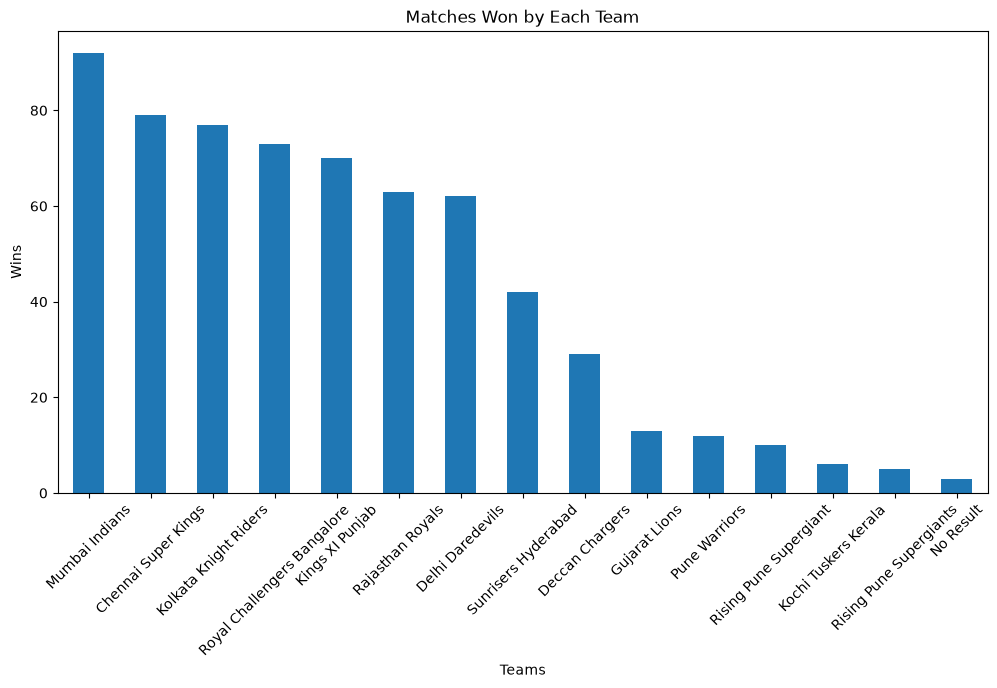

In [37]:
plt.figure(figsize=(12,6))

team_wins.plot(kind="bar")

plt.title("Matches Won by Each Team")
plt.xlabel("Teams")
plt.ylabel("Wins")

plt.xticks(rotation=45)
plt.savefig("../Images/team_wins.png",dpi=300,bbox_inches="tight")

plt.show()

Mumbai Indians had won the highest number of IPL matches,reflecting their consistent performance across multiple seasons.

In [24]:
top5 = team_wins.head(5)

print(top5)

winner
Mumbai Indians                 92
Chennai Super Kings            79
Kolkata Knight Riders          77
Royal Challengers Bangalore    73
Kings XI Punjab                70
Name: count, dtype: int64


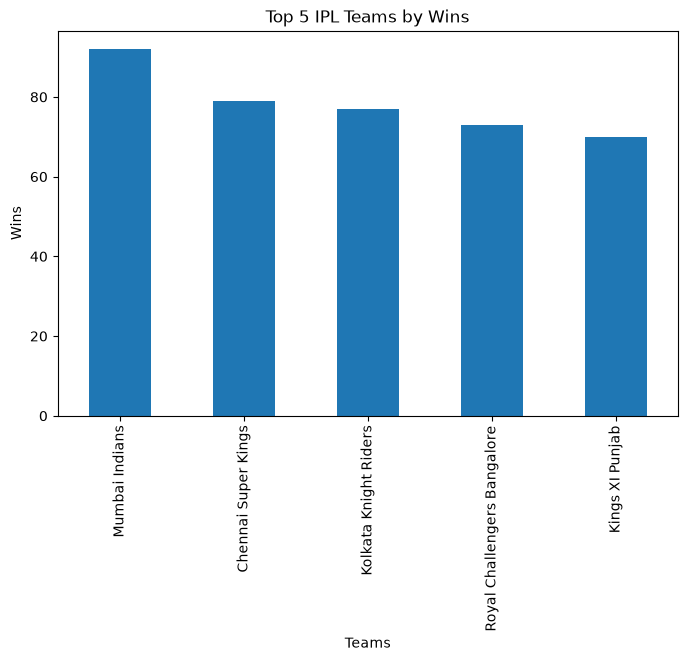

In [38]:
plt.figure(figsize=(8,5))

top5.plot(kind="bar")

plt.title("Top 5 IPL Teams by Wins")
plt.xlabel("Teams")
plt.ylabel("Wins")
plt.savefig("../Images/top5_winners.png",dpi=300,bbox_inches="tight")
plt.show()

The top 5 highest match  winners teams in IPL are MI,CSK,KKR,RCB and KXIP.

In [26]:
toss_wins = matches["toss_winner"].value_counts()

print(toss_wins)

toss_winner
Mumbai Indians                 85
Kolkata Knight Riders          78
Delhi Daredevils               72
Royal Challengers Bangalore    70
Kings XI Punjab                68
Chennai Super Kings            66
Rajasthan Royals               63
Deccan Chargers                43
Sunrisers Hyderabad            35
Pune Warriors                  20
Gujarat Lions                  15
Kochi Tuskers Kerala            8
Rising Pune Supergiants         7
Rising Pune Supergiant          6
Name: count, dtype: int64


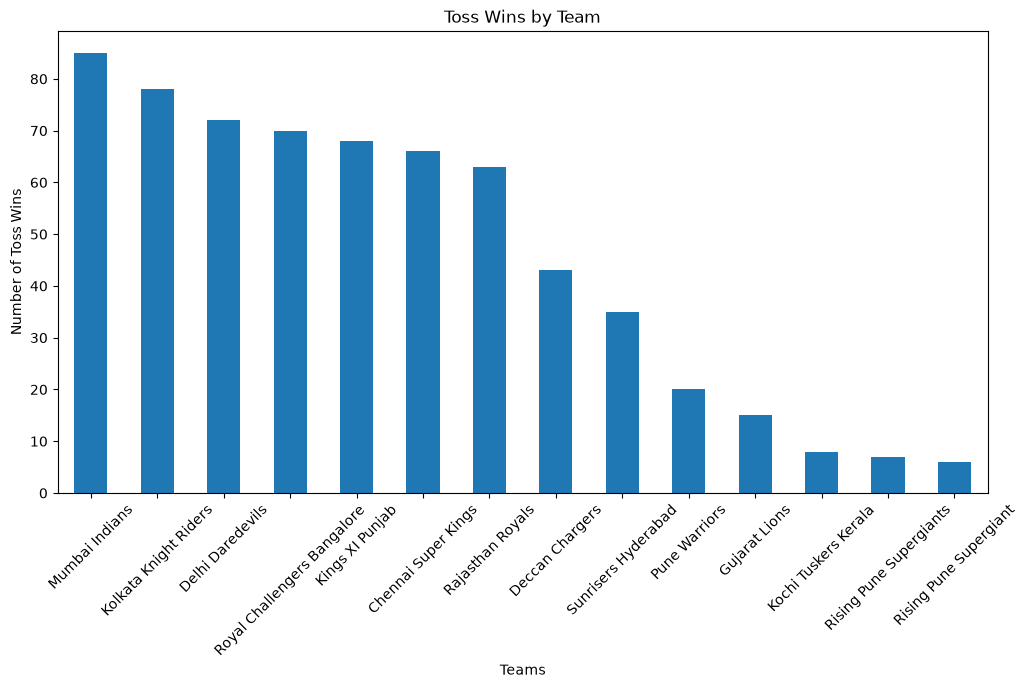

In [43]:
plt.figure(figsize=(12,6))

toss_wins.plot(kind="bar")

plt.title("Toss Wins by Team")
plt.xlabel("Teams")
plt.ylabel("Number of Toss Wins")

plt.xticks(rotation=45)
plt.savefig("../images/toss_wins.png",dpi=300,bbox_inches="tight")
plt.show()

The highest number of tosses is won by Mumbai Indians showing luck is with them.

In [28]:
matches["toss_decision"].value_counts()

toss_decision
field    363
bat      273
Name: count, dtype: int64

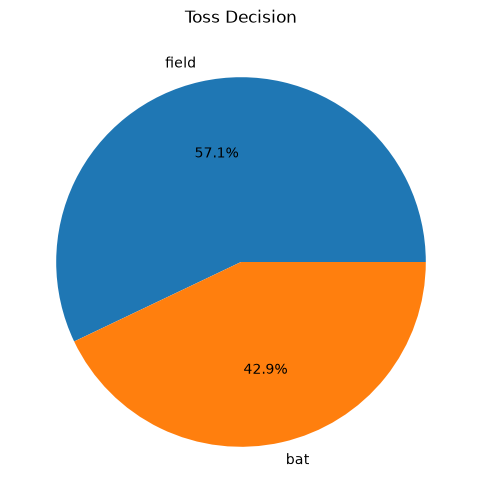

In [40]:
decision = matches["toss_decision"].value_counts()

plt.figure(figsize=(6,6))

decision.plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")

plt.title("Toss Decision")
plt.savefig("../images/toss_decisions.png",dpi=300,bbox_inches="tight")
plt.show()

If a team wons a toss , there is more chances of chosing fielding first.

In [ ]:

season_matches = matches.groupby("season").size()
print(season_matches)

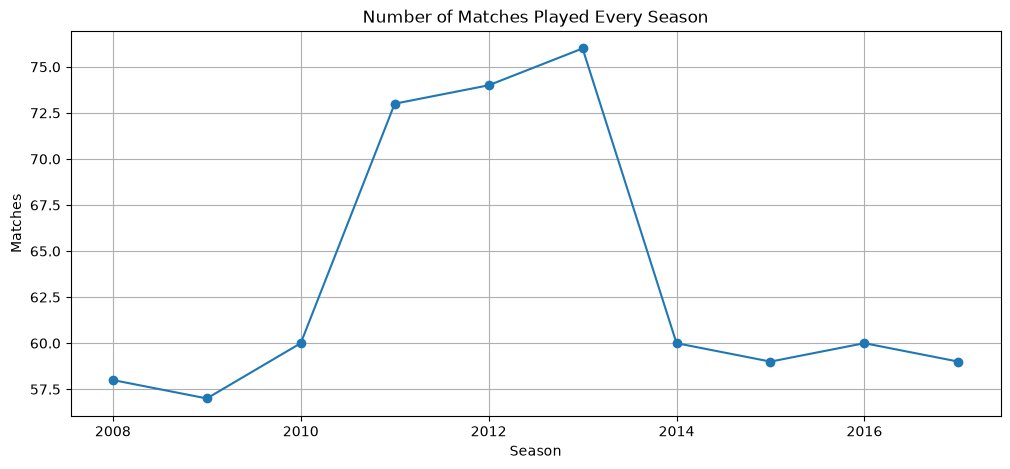

In [42]:
plt.figure(figsize=(12,5))

season_matches.plot(kind="line", marker="o")

plt.title("Number of Matches Played Every Season")
plt.xlabel("Season")
plt.ylabel("Matches")

plt.grid(True)
plt.savefig("../images/season_matches.png",dpi=300,bbox_inches="tight")
plt.show()

The maximum number of matches are played during season 2011 to 2013.

In [32]:
team1 = matches["team1"].value_counts()
team2 = matches["team2"].value_counts()

matches_played = team1 + team2

In [33]:
wins = matches["winner"].value_counts()

In [34]:
win_percentage = (wins / matches_played) * 100

print(win_percentage.sort_values(ascending=False))

winner
Rising Pune Supergiant         62.500000
Chennai Super Kings            60.305344
Mumbai Indians                 58.598726
Sunrisers Hyderabad            55.263158
Rajasthan Royals               53.389831
Kolkata Knight Riders          52.027027
Royal Challengers Bangalore    48.026316
Kings XI Punjab                47.297297
Gujarat Lions                  43.333333
Kochi Tuskers Kerala           42.857143
Delhi Daredevils               42.176871
Deccan Chargers                38.666667
Rising Pune Supergiants        35.714286
Pune Warriors                  26.086957
No Result                            NaN
Name: count, dtype: float64


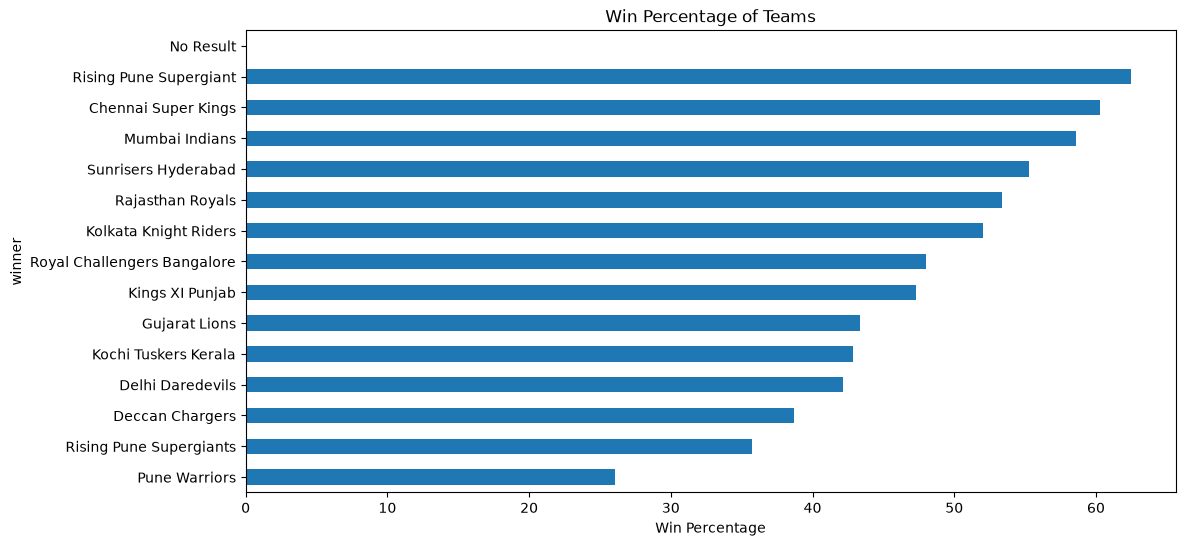

In [41]:
plt.figure(figsize=(12,6))

win_percentage.sort_values().plot(kind="barh")

plt.xlabel("Win Percentage")

plt.title("Win Percentage of Teams")
plt.savefig("../images/win_percentge.png",dpi=300,bbox_inches="tight")

plt.show()

Rising Pune Supergiants have maximum winning percentage which means if they play a match then they have more chances of winnig the match.

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

matches = pd.read_csv("../data/cleaned/matches_cleaned.csv")
deliveries = pd.read_csv("../data/cleaned/deliveries_cleaned.csv")

In [45]:
runs = deliveries.groupby("batsman")["batsman_runs"].sum()

runs = runs.sort_values(ascending=False)

print(runs.head(10))

batsman
SK Raina          4548
V Kohli           4423
RG Sharma         4207
G Gambhir         4132
DA Warner         4014
RV Uthappa        3778
CH Gayle          3651
S Dhawan          3561
MS Dhoni          3560
AB de Villiers    3486
Name: batsman_runs, dtype: int64


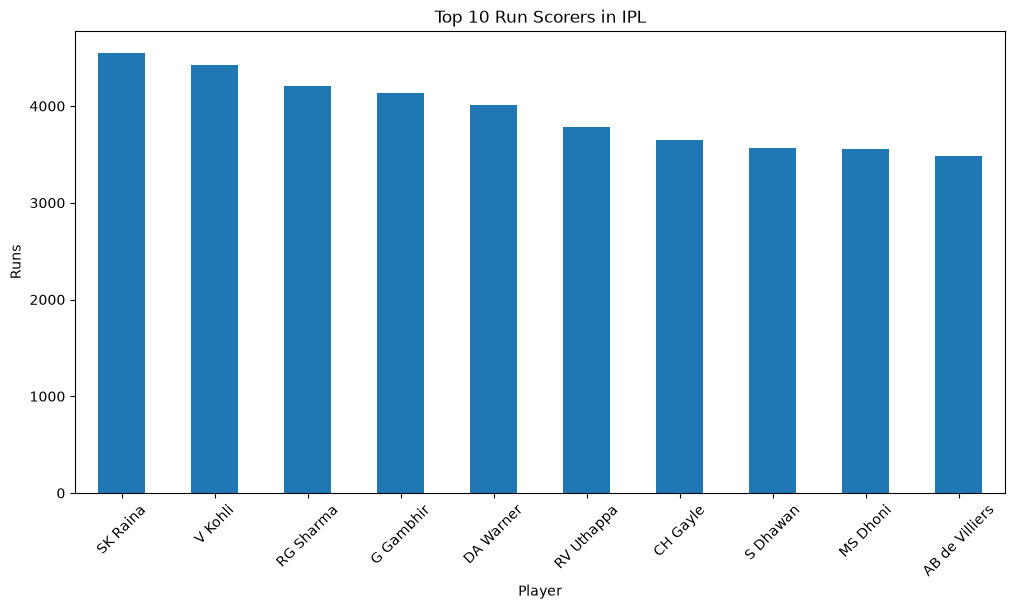

In [46]:
top10_runs = runs.head(10)

plt.figure(figsize=(12,6))

top10_runs.plot(kind="bar")

plt.title("Top 10 Run Scorers in IPL")

plt.xlabel("Player")

plt.ylabel("Runs")

plt.xticks(rotation=45)

plt.savefig("../images/orange_cap.png",dpi=300,bbox_inches="tight")

plt.show()
plt.close()

Only the top 5 players have crossed 4000 runs and maximum runs are scored by SK Raina showing his consistent performance.

In [47]:
wickets = deliveries["player_dismissed"].value_counts()

print(wickets.head(10))

player_dismissed
SK Raina        134
G Gambhir       131
RG Sharma       129
RV Uthappa      128
V Kohli         118
KD Karthik      117
S Dhawan        109
PA Patel        107
Yuvraj Singh    101
DA Warner       100
Name: count, dtype: int64


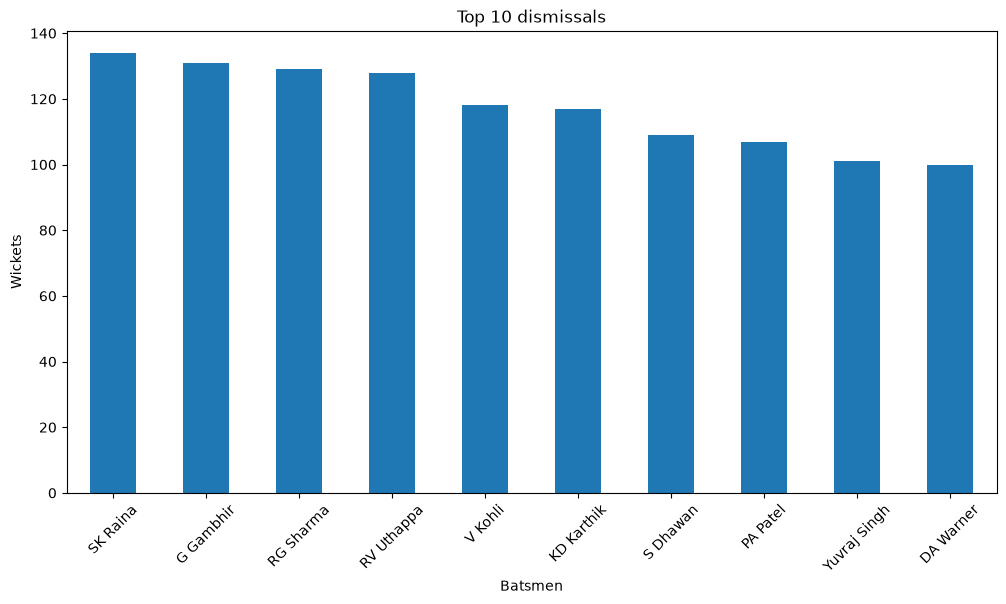

In [50]:
top10_wickets = wickets.head(10)

plt.figure(figsize=(12,6))

top10_wickets.plot(kind="bar")

plt.title("Top 10 dismissals")

plt.xlabel("Batsmen")

plt.ylabel("Wickets")

plt.xticks(rotation=45)

plt.savefig("../images/purple_cap.png",dpi=300,bbox_inches="tight")

plt.show()
plt.close()

SK Raina had been dismissed maximum time which means he has played a lot of matches then other players.

In [52]:
sixes = deliveries[deliveries["batsman_runs"]==6]

top_sixes = sixes["batsman"].value_counts().head(10)

print(top_sixes)

batsman
CH Gayle          266
SK Raina          174
RG Sharma         173
DA Warner         160
V Kohli           160
AB de Villiers    158
MS Dhoni          156
YK Pathan         149
KA Pollard        148
Yuvraj Singh      141
Name: count, dtype: int64


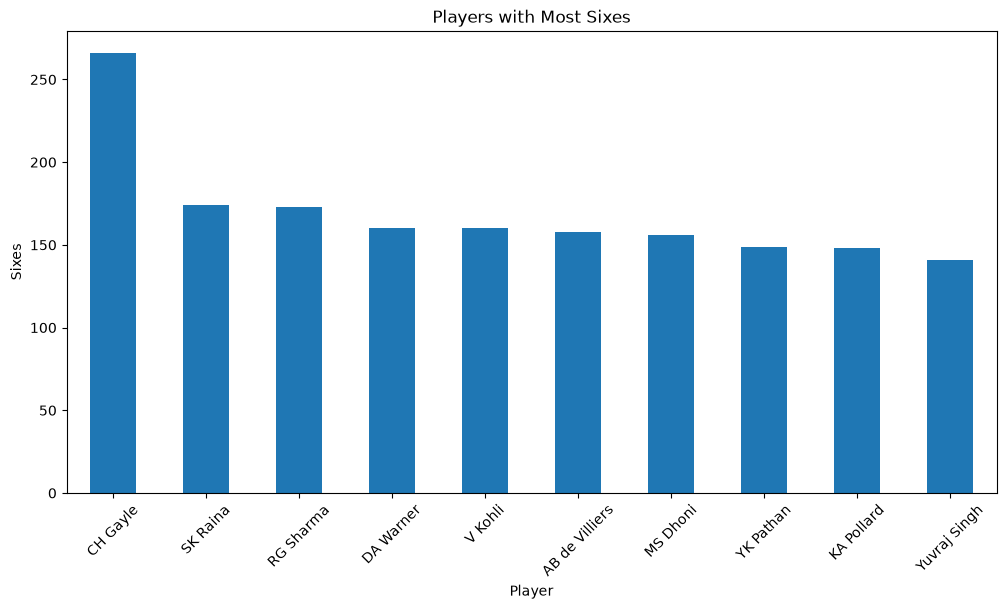

In [53]:
plt.figure(figsize=(12,6))

top_sixes.plot(kind="bar")

plt.title("Players with Most Sixes")

plt.xlabel("Player")

plt.ylabel("Sixes")

plt.xticks(rotation=45)

plt.savefig("../images/most_sixes.png",dpi=300,bbox_inches="tight")

plt.show()
plt.close()

Chris Gayle had maximum number of sixes which is why he was called universe boss.

In [54]:
fours = deliveries[deliveries["batsman_runs"]==4]

top_fours = fours["batsman"].value_counts().head(10)

print(top_fours)

batsman
G Gambhir     484
SK Raina      402
DA Warner     401
S Dhawan      401
V Kohli       384
RV Uthappa    377
RG Sharma     354
V Sehwag      334
AM Rahane     320
CH Gayle      297
Name: count, dtype: int64


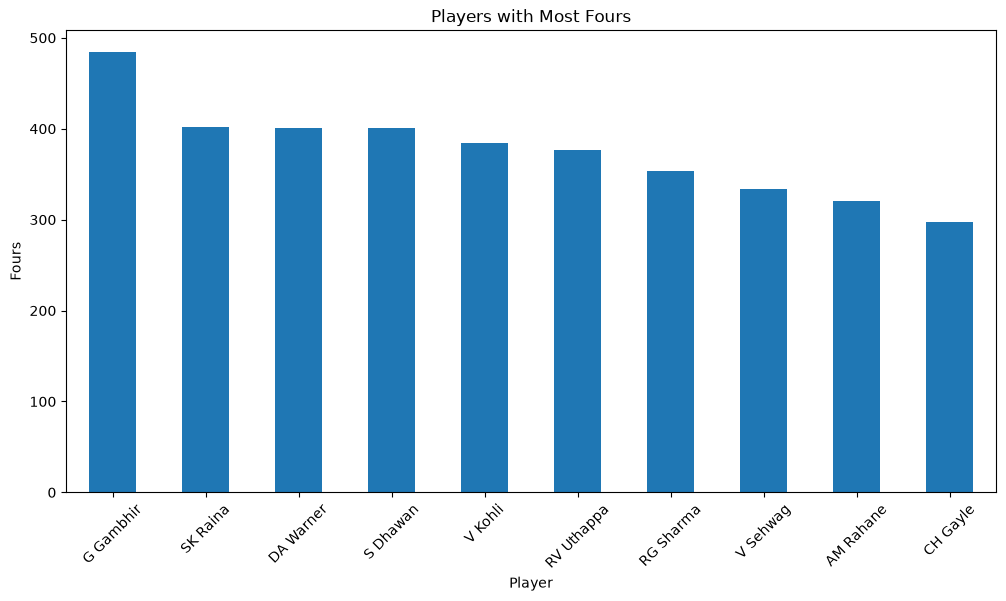

In [55]:
plt.figure(figsize=(12,6))

top_fours.plot(kind="bar")

plt.title("Players with Most Fours")

plt.xlabel("Player")

plt.ylabel("Fours")

plt.xticks(rotation=45)

plt.savefig("../images/most_fours.png",dpi=300,bbox_inches="tight")

plt.show()
plt.close()

Gautam Gambhir had maximum number of fours.

In [56]:
pom = matches["player_of_match"].value_counts()

print(pom.head(10))

player_of_match
CH Gayle          18
YK Pathan         16
DA Warner         15
AB de Villiers    15
SK Raina          14
RG Sharma         14
MS Dhoni          13
G Gambhir         13
MEK Hussey        12
AM Rahane         12
Name: count, dtype: int64


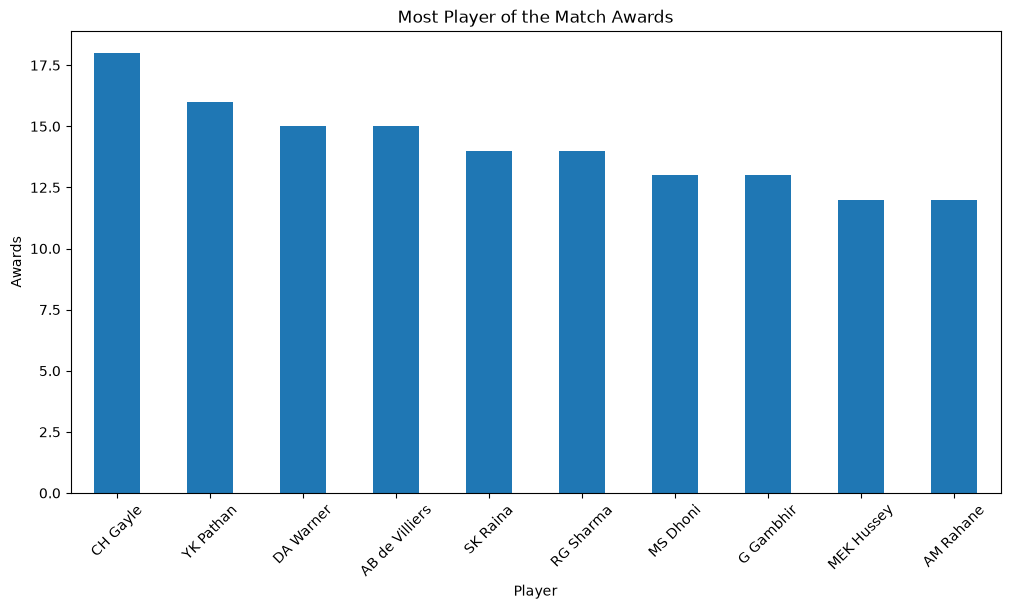

In [57]:
plt.figure(figsize=(12,6))

pom.head(10).plot(kind="bar")

plt.title("Most Player of the Match Awards")

plt.xlabel("Player")

plt.ylabel("Awards")

plt.xticks(rotation=45)

plt.savefig("../images/player_of_match.png",dpi=300,bbox_inches="tight")

plt.show()
plt.close()

Chris Gayle became player of the match maximum times.

In [58]:
runs = deliveries.groupby("batsman")["batsman_runs"].sum()

In [59]:
balls = deliveries.groupby("batsman").size()

In [60]:
strike_rate = (runs / balls) * 100

In [61]:
qualified = balls >= 500

strike_rate = strike_rate[qualified].sort_values(ascending=False)

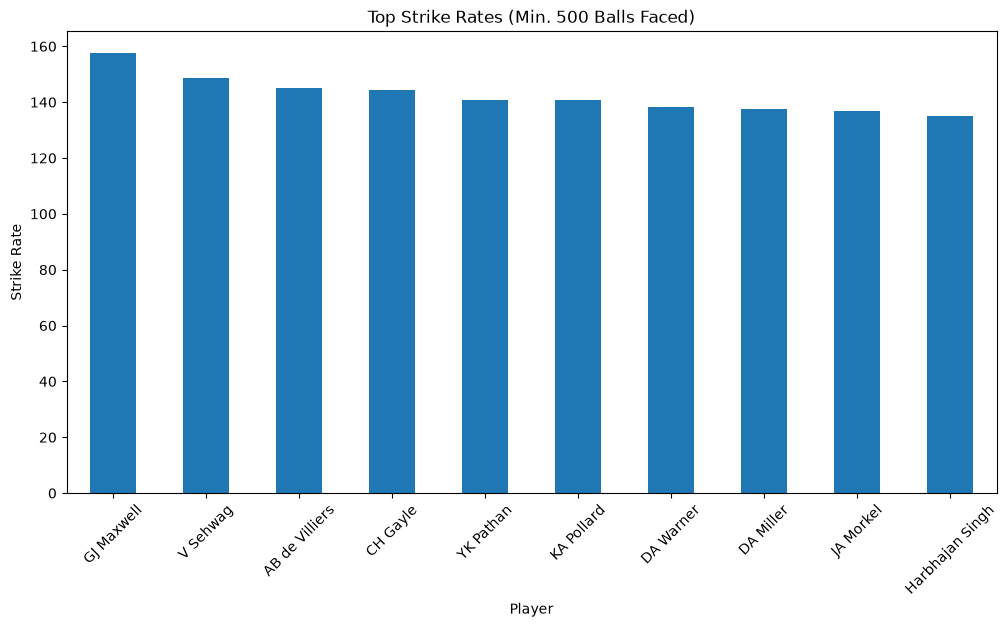

In [62]:
plt.figure(figsize=(12,6))

strike_rate.head(10).plot(kind="bar")

plt.title("Top Strike Rates (Min. 500 Balls Faced)")

plt.xlabel("Player")

plt.ylabel("Strike Rate")

plt.xticks(rotation=45)

plt.savefig("../images/strike_rate.png",dpi=300,bbox_inches="tight")

plt.show()
plt.close()

GJ Maxwell had the maximum strike rate among players who faced at least 500 balls.

In [63]:
runs_conceded = deliveries.groupby("bowler")["total_runs"].sum()

balls_bowled = deliveries.groupby("bowler").size()

overs = balls_bowled / 6

economy = runs_conceded / overs

In [64]:
qualified = balls_bowled >= 300

economy = economy[qualified].sort_values()

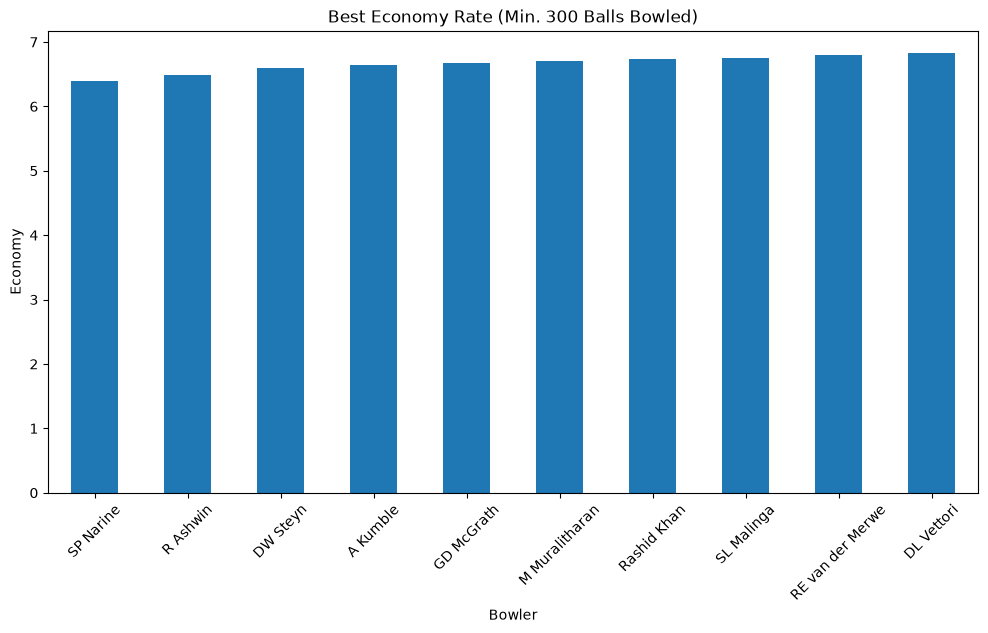

In [65]:
plt.figure(figsize=(12,6))

economy.head(10).plot(kind="bar")

plt.title("Best Economy Rate (Min. 300 Balls Bowled)")

plt.xlabel("Bowler")

plt.ylabel("Economy")

plt.xticks(rotation=45)

plt.savefig("../images/economy.png",dpi=300,bbox_inches="tight")

plt.show()
plt.close()

SP Narine maintained the best economy rate among bowlers who bowled at least 300 balls.

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

matches = pd.read_csv("../data/cleaned/matches_cleaned.csv")
deliveries = pd.read_csv("../data/cleaned/deliveries_cleaned.csv")

In [67]:
print(matches["venue"].unique())

<ArrowStringArray>
[           'Rajiv Gandhi International Stadium, Uppal',
              'Maharashtra Cricket Association Stadium',
               'Saurashtra Cricket Association Stadium',
                               'Holkar Cricket Stadium',
                                'M Chinnaswamy Stadium',
                                     'Wankhede Stadium',
                                         'Eden Gardens',
                                     'Feroz Shah Kotla',
 'Punjab Cricket Association IS Bindra Stadium, Mohali',
                                           'Green Park',
           'Punjab Cricket Association Stadium, Mohali',
                               'Sawai Mansingh Stadium',
                      'MA Chidambaram Stadium, Chepauk',
                           'Dr DY Patil Sports Academy',
                                             'Newlands',
                                     'St George's Park',
                                            'Kingsmead',
            

In [68]:
venue_matches = matches["venue"].value_counts()

print(venue_matches)

venue
M Chinnaswamy Stadium                                   66
Eden Gardens                                            61
Feroz Shah Kotla                                        60
Wankhede Stadium                                        57
Rajiv Gandhi International Stadium, Uppal               49
MA Chidambaram Stadium, Chepauk                         48
Punjab Cricket Association Stadium, Mohali              35
Sawai Mansingh Stadium                                  33
Dr DY Patil Sports Academy                              17
Subrata Roy Sahara Stadium                              17
Maharashtra Cricket Association Stadium                 15
Kingsmead                                               15
SuperSport Park                                         12
Sardar Patel Stadium, Motera                            12
Punjab Cricket Association IS Bindra Stadium, Mohali    11
Brabourne Stadium                                       11
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadiu

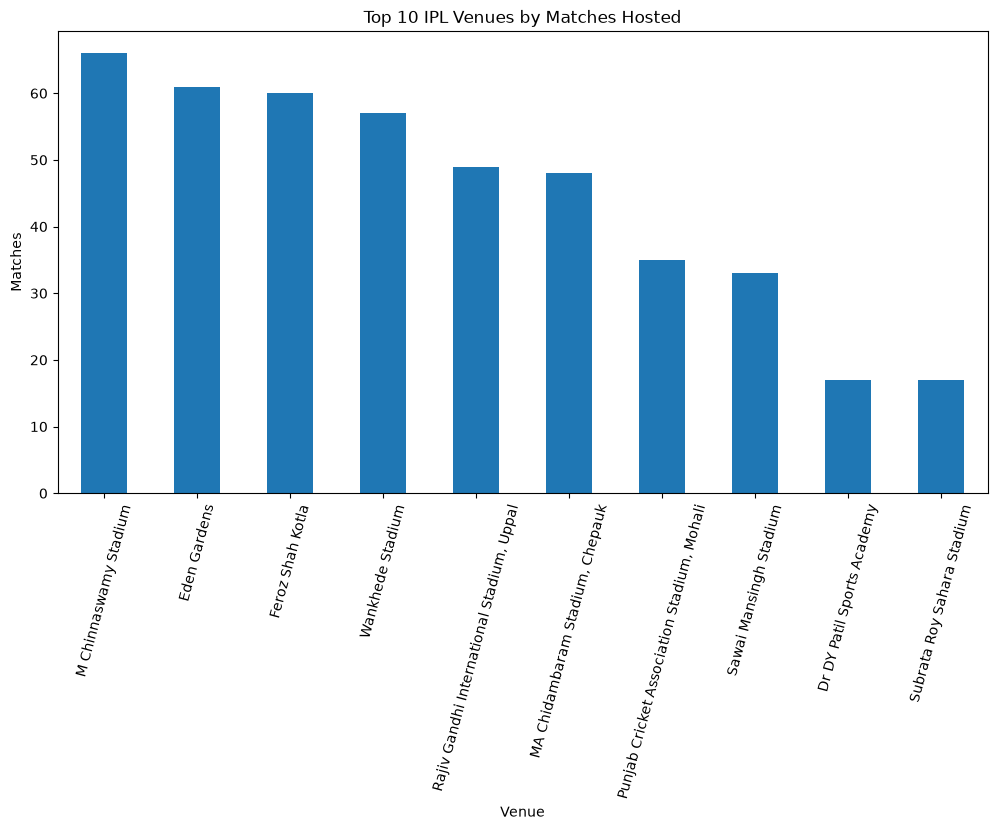

In [69]:
top10_venues = venue_matches.head(10)

plt.figure(figsize=(12,6))

top10_venues.plot(kind="bar")

plt.title("Top 10 IPL Venues by Matches Hosted")
plt.xlabel("Venue")
plt.ylabel("Matches")

plt.xticks(rotation=75)

plt.savefig("../images/top_venues.png",
            dpi=300,
            bbox_inches="tight")

plt.show()
plt.close()

M Chinnaswamy Stadium hosted the highest number of IPL matches.

In [70]:
venue_team = matches.groupby(["venue","winner"]).size()

print(venue_team.head(20))

venue                       winner                     
Barabati Stadium            Deccan Chargers                3
                            Kings XI Punjab                1
                            Kolkata Knight Riders          3
Brabourne Stadium           Chennai Super Kings            1
                            Mumbai Indians                 6
                            Rajasthan Royals               2
                            Royal Challengers Bangalore    1
                            Sunrisers Hyderabad            1
Buffalo Park                Chennai Super Kings            1
                            Delhi Daredevils               1
                            Mumbai Indians                 1
De Beers Diamond Oval       Chennai Super Kings            1
                            Deccan Chargers                1
                            Kings XI Punjab                1
Dr DY Patil Sports Academy  Chennai Super Kings            3
                            D

In [71]:
venue_team = venue_team.reset_index(name="wins")

print(venue_team.head())

               venue                 winner  wins
0   Barabati Stadium        Deccan Chargers     3
1   Barabati Stadium        Kings XI Punjab     1
2   Barabati Stadium  Kolkata Knight Riders     3
3  Brabourne Stadium    Chennai Super Kings     1
4  Brabourne Stadium         Mumbai Indians     6


In [72]:
best_team = venue_team.loc[
    venue_team.groupby("venue")["wins"].idxmax()
]

print(best_team)

                                                 venue  \
0                                     Barabati Stadium   
4                                    Brabourne Stadium   
8                                         Buffalo Park   
11                               De Beers Diamond Oval   
18                          Dr DY Patil Sports Academy   
28   Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...   
29                 Dubai International Cricket Stadium   
39                                        Eden Gardens   
46                                    Feroz Shah Kotla   
59                                          Green Park   
64        Himachal Pradesh Cricket Association Stadium   
65                              Holkar Cricket Stadium   
68                  JSCA International Stadium Complex   
75                                           Kingsmead   
90                               M Chinnaswamy Stadium   
92                     MA Chidambaram Stadium, Chepauk   
106           

In [73]:
best_team.to_csv(
    "../data/cleaned/best_team_per_venue.csv",index=False)

In [74]:
merged = deliveries.merge(matches[["id","venue"]],left_on="match_id",right_on="id")

In [75]:
innings_score = merged.groupby(
    ["match_id","inning"]
)["total_runs"].sum().reset_index()

In [76]:
innings_score = innings_score.merge(matches[["id","venue"]],left_on="match_id",right_on="id")

In [77]:
first = innings_score[innings_score["inning"]==1]

In [78]:
avg_first = first.groupby("venue")["total_runs"].mean()

print(avg_first.sort_values(ascending=False))

venue
Brabourne Stadium                                       180.272727
Himachal Pradesh Cricket Association Stadium            175.666667
Saurashtra Cricket Association Stadium                  168.900000
M Chinnaswamy Stadium                                   167.893939
Barabati Stadium                                        167.714286
Maharashtra Cricket Association Stadium                 166.600000
MA Chidambaram Stadium, Chepauk                         166.020833
Punjab Cricket Association IS Bindra Stadium, Mohali    164.090909
Wankhede Stadium                                        163.947368
Punjab Cricket Association Stadium, Mohali              163.285714
Sardar Patel Stadium, Motera                            163.166667
Feroz Shah Kotla                                        161.633333
Green Park                                              161.250000
St George's Park                                        159.000000
Sharjah Cricket Stadium                                 

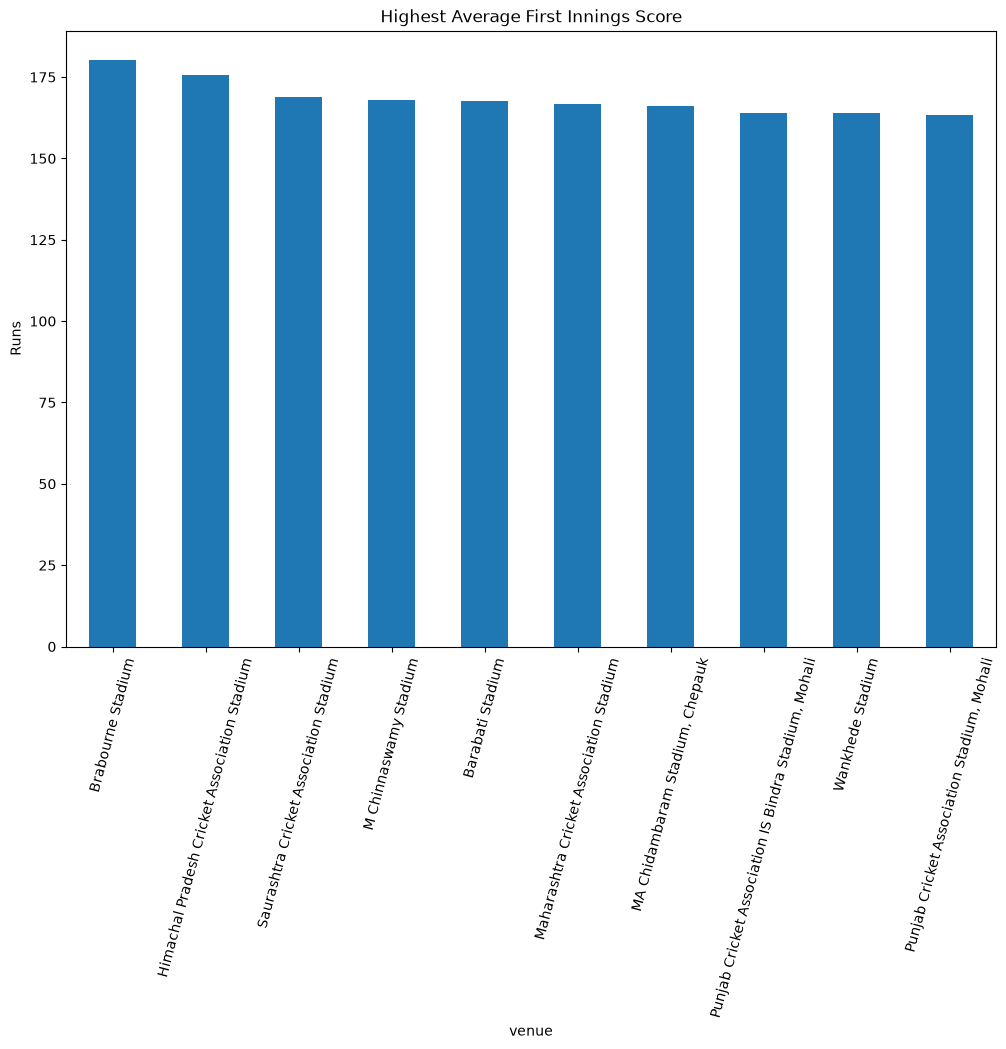

In [79]:
plt.figure(figsize=(12,8))

avg_first.sort_values(
    ascending=False
).head(10).plot(kind="bar")

plt.title("Highest Average First Innings Score")

plt.ylabel("Runs")

plt.xticks(rotation=75)

plt.savefig("../images/highest_first_innings.png",
dpi=300,
bbox_inches="tight")

plt.show()
plt.close()

The average score for first inning is highest in stadium Brabourne Stadium.

In [80]:
second = innings_score[innings_score["inning"]==2]

avg_second = second.groupby("venue")["total_runs"].mean()

print(avg_second.sort_values(ascending=False))

venue
Brabourne Stadium                                       168.909091
Green Park                                              163.250000
Saurashtra Cricket Association Stadium                  162.700000
Holkar Cricket Stadium                                  158.400000
Punjab Cricket Association IS Bindra Stadium, Mohali    158.181818
Barabati Stadium                                        157.714286
MA Chidambaram Stadium, Chepauk                         151.854167
Wankhede Stadium                                        151.684211
Maharashtra Cricket Association Stadium                 150.866667
Punjab Cricket Association Stadium, Mohali              150.628571
SuperSport Park                                         149.583333
Sardar Patel Stadium, Motera                            149.000000
Feroz Shah Kotla                                        147.847458
Rajiv Gandhi International Stadium, Uppal               146.979592
Sharjah Cricket Stadium                                 

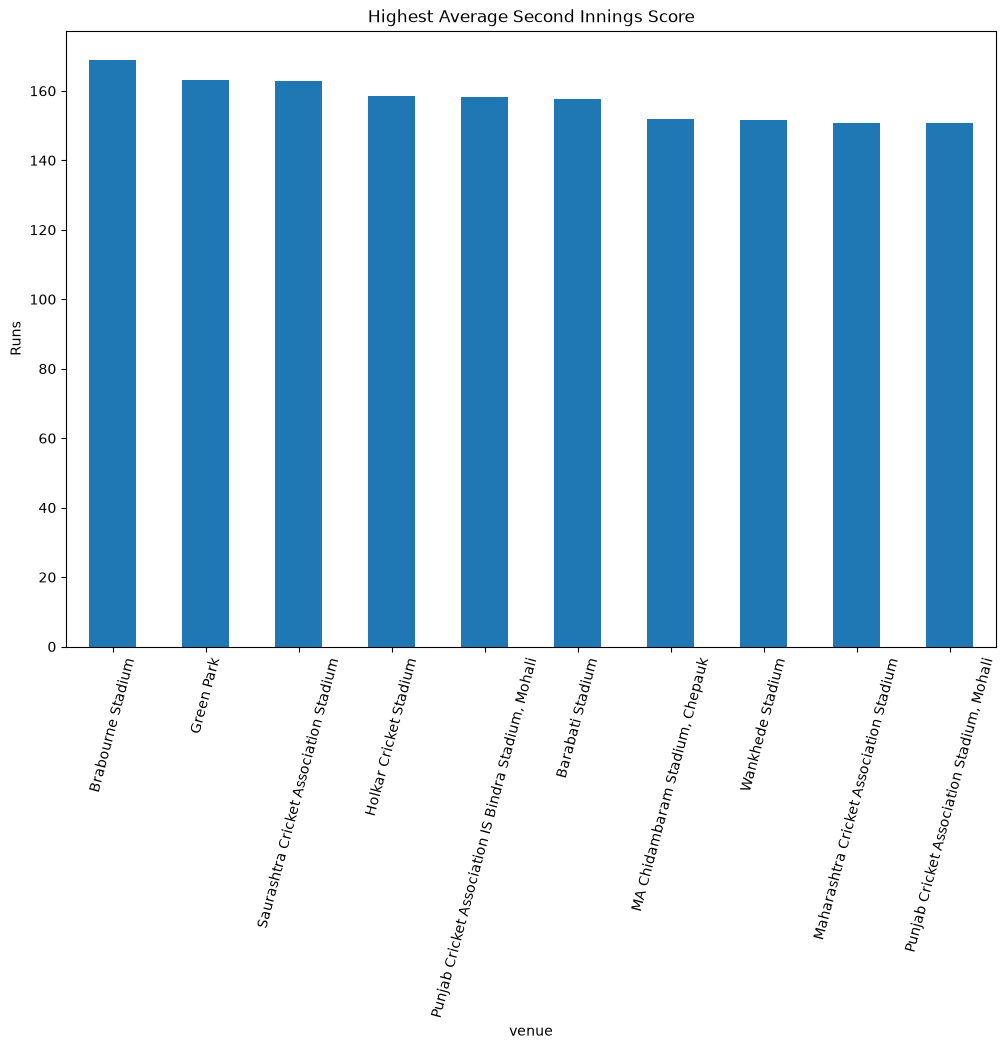

In [82]:
plt.figure(figsize=(12,8))

avg_second.sort_values(
    ascending=False
).head(10).plot(kind="bar")

plt.title("Highest Average Second Innings Score")

plt.ylabel("Runs")

plt.xticks(rotation=75)

plt.savefig("../images/highest_second_innings.png",
dpi=300,
bbox_inches="tight")

plt.show()
plt.close()

The average score for second inning is highest for Brabourne Stadium.

In [83]:
print(avg_first.idxmax())
print(avg_first.max())

Brabourne Stadium
180.27272727272728


In [84]:
print(avg_first.idxmin())
print(avg_first.min())

OUTsurance Oval
135.0


In [85]:
matches["chasing_win"] = matches["win_by_wickets"] > 0

In [86]:
venue_chasing = matches.groupby("venue")["chasing_win"].mean()*100

print(venue_chasing.sort_values(ascending=False))

venue
Green Park                                              100.000000
Holkar Cricket Stadium                                  100.000000
JSCA International Stadium Complex                       71.428571
Sawai Mansingh Stadium                                   69.696970
Shaheed Veer Narayan Singh International Stadium         66.666667
SuperSport Park                                          66.666667
Sharjah Cricket Stadium                                  66.666667
Maharashtra Cricket Association Stadium                  66.666667
De Beers Diamond Oval                                    66.666667
New Wanderers Stadium                                    62.500000
Saurashtra Cricket Association Stadium                   60.000000
Eden Gardens                                             59.016393
Dr DY Patil Sports Academy                               58.823529
St George's Park                                         57.142857
Dubai International Cricket Stadium                     

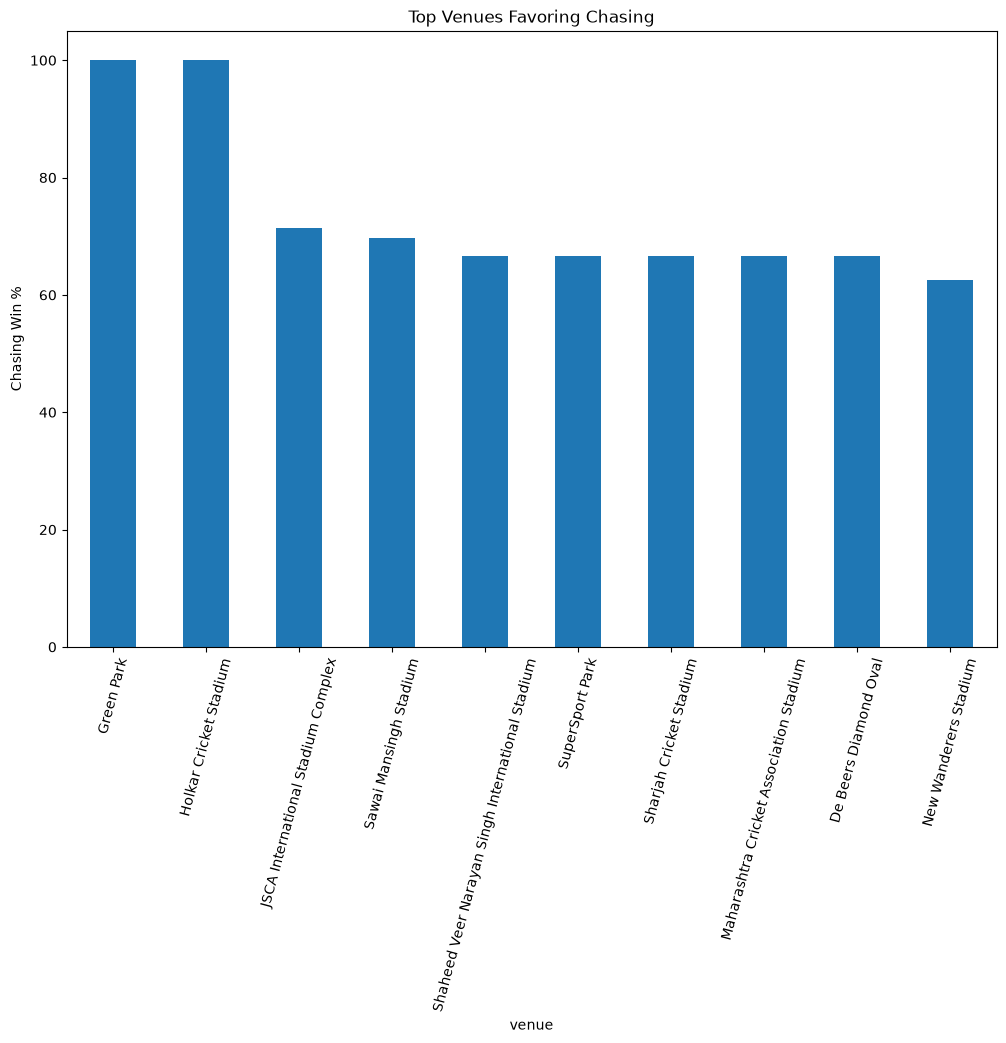

In [87]:
plt.figure(figsize=(12,8))

venue_chasing.sort_values(
ascending=False
).head(10).plot(kind="bar")

plt.title("Top Venues Favoring Chasing")

plt.ylabel("Chasing Win %")

plt.xticks(rotation=75)

plt.savefig("../images/chasing_venues.png",
dpi=300,
bbox_inches="tight")

plt.show()
plt.close()

The teams who have chased score in Green Park and Holkar Cricket Stadium have win rate of 100 percent.

In [88]:
avg_first.to_csv("../data/cleaned/average_first_innings.csv")

avg_second.to_csv("../data/cleaned/average_second_innings.csv")

In [89]:
import pandas as pd
import matplotlib.pyplot as plt

matches = pd.read_csv("../data/cleaned/matches_cleaned.csv")
deliveries = pd.read_csv("../data/cleaned/deliveries_cleaned.csv")

In [90]:
season_matches = matches.groupby("season").size()

print(season_matches)

season
2008    58
2009    57
2010    60
2011    73
2012    74
2013    76
2014    60
2015    59
2016    60
2017    59
dtype: int64


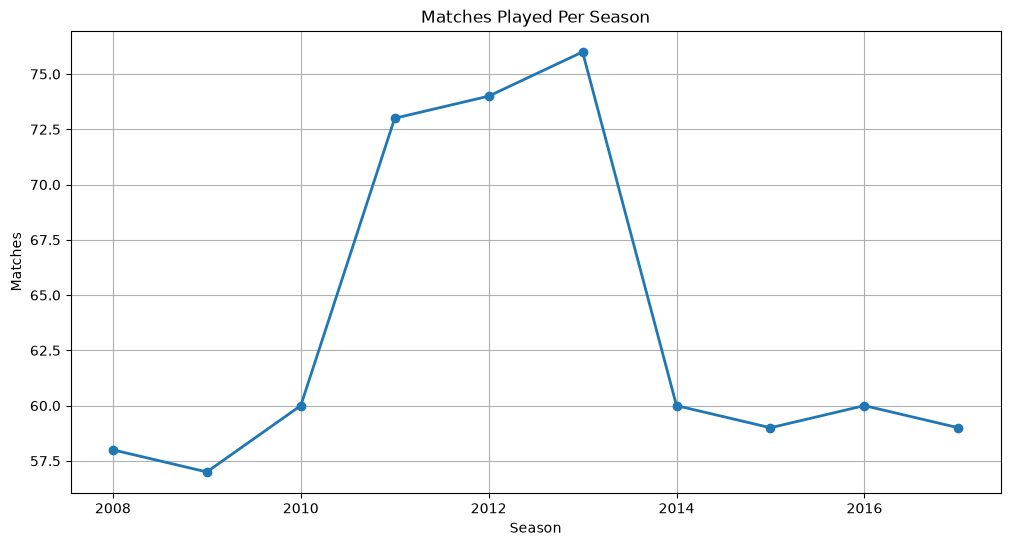

In [91]:
plt.figure(figsize=(12,6))

season_matches.plot(
    kind="line",
    marker="o",
    linewidth=2
)

plt.title("Matches Played Per Season")
plt.xlabel("Season")
plt.ylabel("Matches")

plt.grid(True)

plt.savefig(
    "../images/matches_per_season.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

The maximum number of matches have been played in season 2013.

In [92]:
merged = deliveries.merge(
    matches[["id","season"]],
    left_on="match_id",
    right_on="id"
)

In [93]:
innings = merged.groupby(
    ["match_id","season","inning"]
)["total_runs"].sum().reset_index()

In [94]:
first = innings[
    innings["inning"]==1
]

In [95]:
avg_first = first.groupby(
    "season"
)["total_runs"].mean()

print(avg_first)

season
2008    160.965517
2009    150.263158
2010    164.766667
2011    152.369863
2012    157.540541
2013    155.894737
2014    163.066667
2015    166.254237
2016    162.600000
2017    165.779661
Name: total_runs, dtype: float64


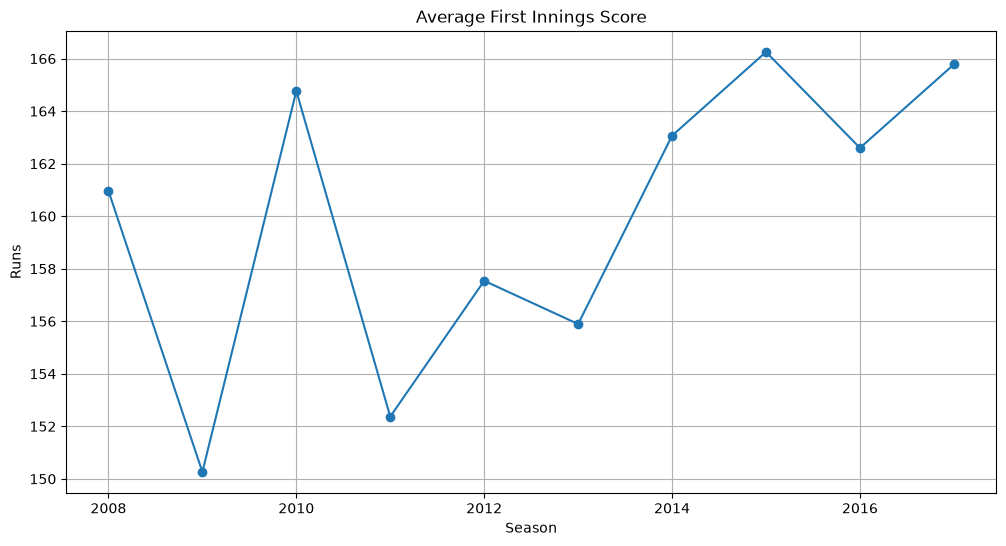

In [96]:
plt.figure(figsize=(12,6))

avg_first.plot(
    marker="o"
)

plt.title("Average First Innings Score")

plt.xlabel("Season")
plt.ylabel("Runs")

plt.grid(True)

plt.savefig(
    "../images/avg_first_innings_season.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

The highest average for first inning was in 2015 which is around 165.

In [97]:
second = innings[
    innings["inning"]==2
]

avg_second = second.groupby(
    "season"
)["total_runs"].mean()

print(avg_second)

season
2008    148.293103
2009    136.052632
2010    149.616667
2011    139.319444
2012    145.878378
2013    140.697368
2014    152.083333
2015    146.948276
2016    151.766667
2017    152.338983
Name: total_runs, dtype: float64


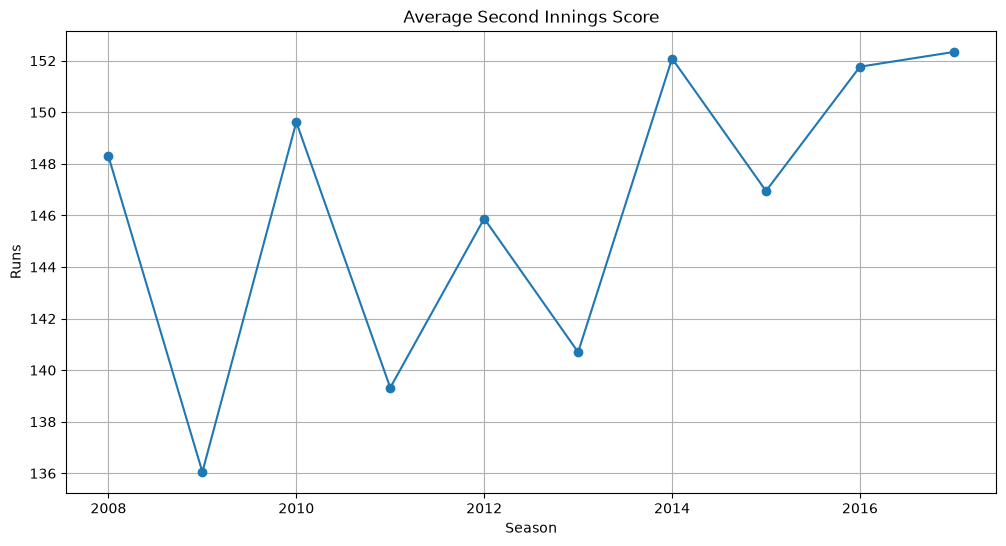

In [98]:
plt.figure(figsize=(12,6))

avg_second.plot(
    marker="o"
)

plt.title("Average Second Innings Score")

plt.xlabel("Season")
plt.ylabel("Runs")

plt.grid(True)

plt.savefig(
    "../images/avg_second_innings_season.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

The highest average for second inning was in year 2017.

In [99]:
matches["date"] = pd.to_datetime(matches["date"])

In [100]:
final_matches = matches.sort_values("date").groupby("season").tail(1)

champions = final_matches[["season", "winner"]]

print(champions)

     season                 winner
116    2008       Rajasthan Royals
173    2009        Deccan Chargers
233    2010    Chennai Super Kings
306    2011    Chennai Super Kings
380    2012  Kolkata Knight Riders
456    2013         Mumbai Indians
516    2014  Kolkata Knight Riders
575    2015         Mumbai Indians
635    2016    Sunrisers Hyderabad
58     2017         Mumbai Indians


In [101]:
toss = matches.groupby(
    ["season","toss_decision"]
).size().unstack(fill_value=0)

print(toss)

toss_decision  bat  field
season                   
2008            26     32
2009            35     22
2010            39     21
2011            25     48
2012            37     37
2013            45     31
2014            19     41
2015            25     34
2016            11     49
2017            11     48


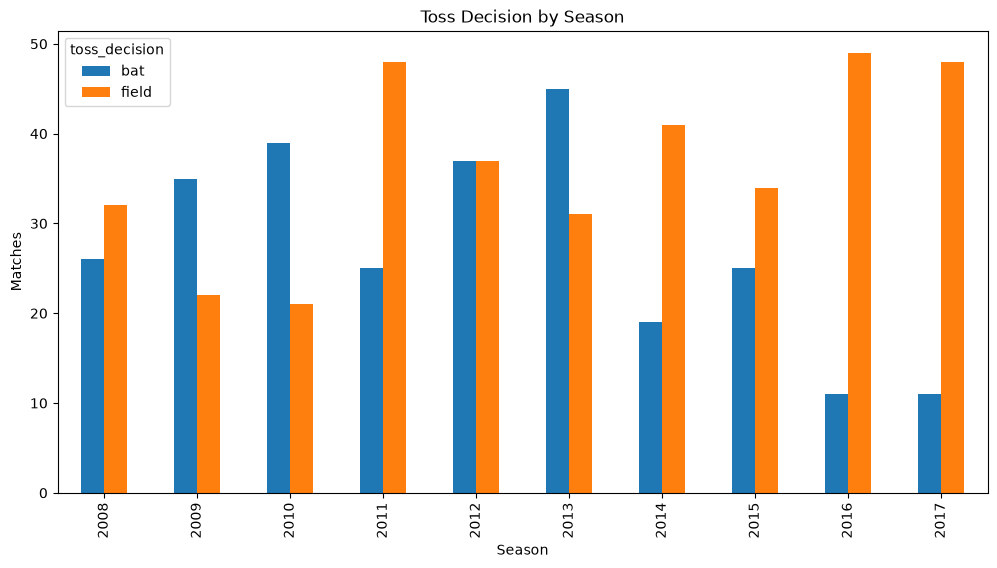

In [102]:
toss.plot(
    figsize=(12,6),
    kind="bar"
)

plt.title("Toss Decision by Season")

plt.xlabel("Season")
plt.ylabel("Matches")

plt.savefig(
    "../images/toss_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [103]:
margin_runs = matches.groupby(
    "season"
)["win_by_runs"].mean()

print(margin_runs)

season
2008    12.155172
2009    13.403509
2010    16.266667
2011    15.041096
2012    12.972973
2013    16.328947
2014    10.733333
2015    14.406780
2016    11.266667
2017    13.355932
Name: win_by_runs, dtype: float64


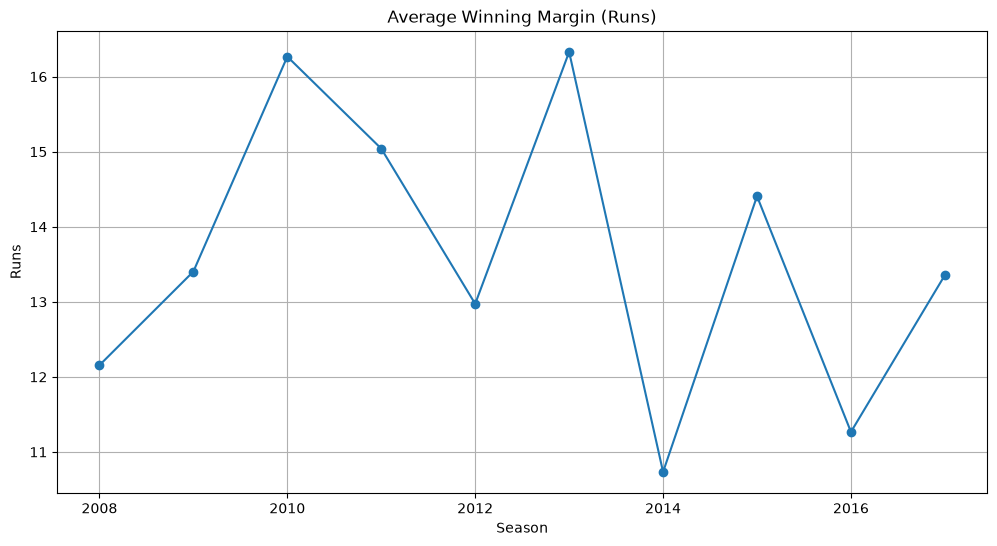

In [104]:
plt.figure(figsize=(12,6))

margin_runs.plot(
    marker="o"
)

plt.title("Average Winning Margin (Runs)")

plt.xlabel("Season")
plt.ylabel("Runs")

plt.grid(True)

plt.savefig(
    "../images/win_margin_runs.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

The highest average winning margin(runs) was in season 2013.

In [105]:
margin_wickets = matches.groupby(
    "season"
)["win_by_wickets"].mean()

print(margin_wickets)

season
2008    3.810345
2009    3.157895
2010    3.166667
2011    3.630137
2012    3.256757
2013    2.986842
2014    3.750000
2015    2.508475
2016    4.066667
2017    3.457627
Name: win_by_wickets, dtype: float64


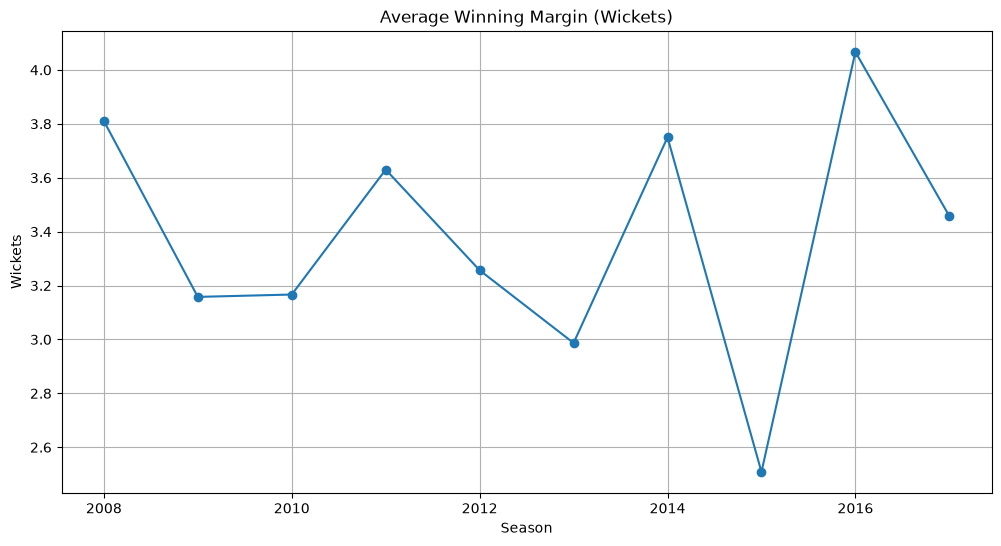

In [106]:
plt.figure(figsize=(12,6))

margin_wickets.plot(
    marker="o"
)

plt.title("Average Winning Margin (Wickets)")

plt.xlabel("Season")
plt.ylabel("Wickets")

plt.grid(True)

plt.savefig(
    "../images/win_margin_wickets.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

The highest average winning margin(wickets) was in 2016.

In [107]:
champions.to_csv(
    "../data/cleaned/champions.csv",
    index=False
)

avg_first.to_csv(
    "../data/cleaned/season_avg_first.csv"
)

avg_second.to_csv(
    "../data/cleaned/season_avg_second.csv"
)

In [108]:
print(matches.columns.tolist())

['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner', 'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2']


In [109]:
import pandas as pd
import matplotlib.pyplot as plt

matches = pd.read_csv("../data/cleaned/matches_cleaned.csv")
deliveries = pd.read_csv("../data/cleaned/deliveries_cleaned.csv")

In [110]:
player_scores = deliveries.groupby(
    ["match_id", "inning", "batsman"]
)["batsman_runs"].sum().reset_index()

print(player_scores.head())

   match_id  inning       batsman  batsman_runs
0         1       1   BCJ Cutting            16
1         1       1     DA Warner            14
2         1       1      DJ Hooda            16
3         1       1  MC Henriques            52
4         1       1      S Dhawan            40


In [111]:
highest_scores = player_scores.sort_values(
    by="batsman_runs",
    ascending=False
)

print(highest_scores.head(10))

      match_id  inning         batsman  batsman_runs
6217       411       1        CH Gayle           175
902         60       1     BB McCullum           158
8458       562       1  AB de Villiers           133
9289       620       1  AB de Villiers           129
5596       372       1        CH Gayle           128
3144       206       1         M Vijay           127
531         36       1       DA Warner           126
7769       516       1        V Sehwag           122
3701       243       2     PC Valthaty           120
4235       279       2        V Sehwag           119


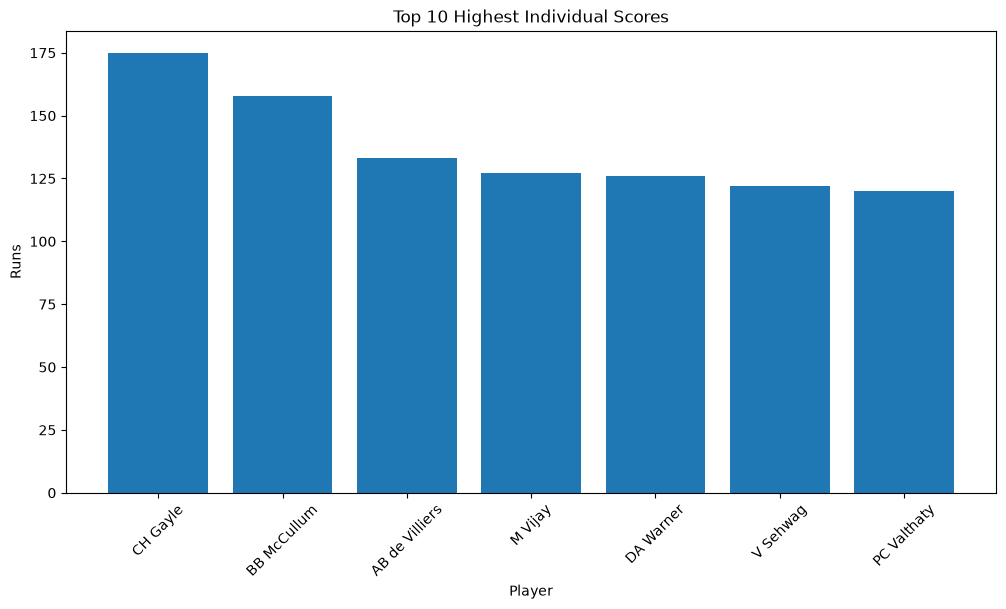

In [112]:
plt.figure(figsize=(12,6))

top10 = highest_scores.head(10)

plt.bar(top10["batsman"], top10["batsman_runs"])

plt.title("Top 10 Highest Individual Scores")

plt.xlabel("Player")
plt.ylabel("Runs")

plt.xticks(rotation=45)

plt.savefig(
    "../images/highest_scores.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

Chris Gayle recorded the highest individual score in the dataset.

In [113]:
runs = deliveries.groupby(
    "batsman"
)["batsman_runs"].sum()

In [114]:
outs = deliveries[
    deliveries["player_dismissed"].notna()
]["player_dismissed"].value_counts()

In [115]:
average = runs / outs

average = average.fillna(0)

average = average.sort_values(
    ascending=False
)

print(average.head(10))

batsman
MN van Wyk        55.666667
V Shankar         50.500000
J Suchith         48.000000
AC Voges          45.250000
HM Amla           44.384615
Iqbal Abdulla     44.000000
CH Gayle          41.022472
PD Collingwood    40.600000
DA Warner         40.140000
LMP Simmons       39.962963
dtype: float64


In [119]:
qualified = average.index.intersection(runs[runs >= 1000].index)

average = average.loc[qualified]

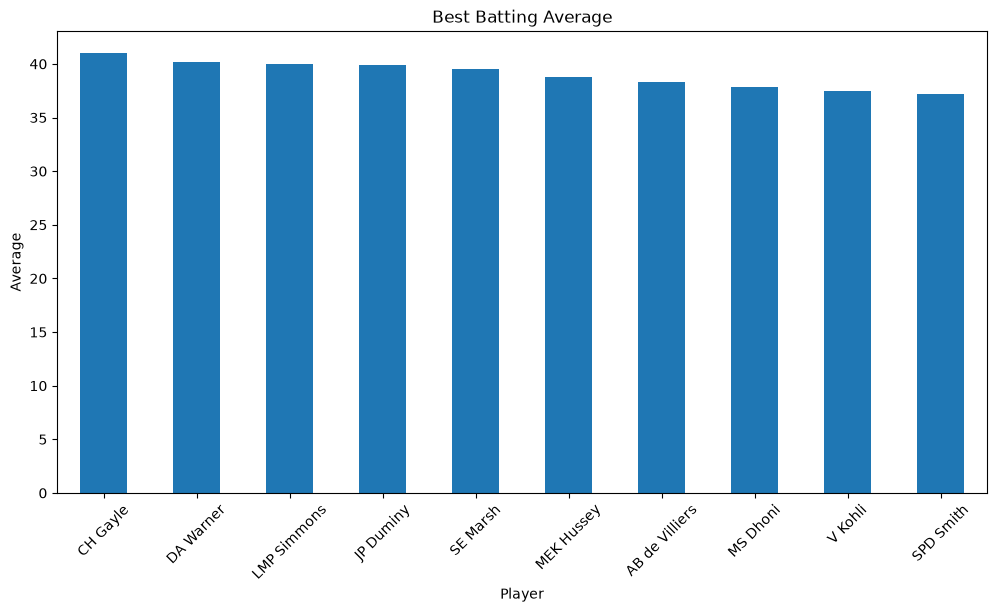

In [120]:
plt.figure(figsize=(12,6))

average.head(10).plot(kind="bar")

plt.title("Best Batting Average")

plt.xlabel("Player")
plt.ylabel("Average")

plt.xticks(rotation=45)

plt.savefig(
    "../images/batting_average.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

Chris Gayle has the highest batting average among players with at least 1000 runs.

In [121]:
legal_balls = deliveries[
    deliveries["wide_runs"] == 0
]

runs = legal_balls.groupby("batsman")["batsman_runs"].sum()

balls = legal_balls.groupby("batsman").size()

strike_rate = (runs / balls) * 100

In [122]:
qualified = balls >= 500

strike_rate = strike_rate[qualified].sort_values(
    ascending=False
)

print(strike_rate.head(10))

batsman
GJ Maxwell         164.304813
V Sehwag           155.441595
CH Gayle           151.556663
AB de Villiers     148.466780
KA Pollard         146.941323
YK Pathan          146.100000
ST Jayasuriya      144.360902
Harbhajan Singh    142.424242
DA Warner          142.088496
JA Morkel          141.921397
dtype: float64


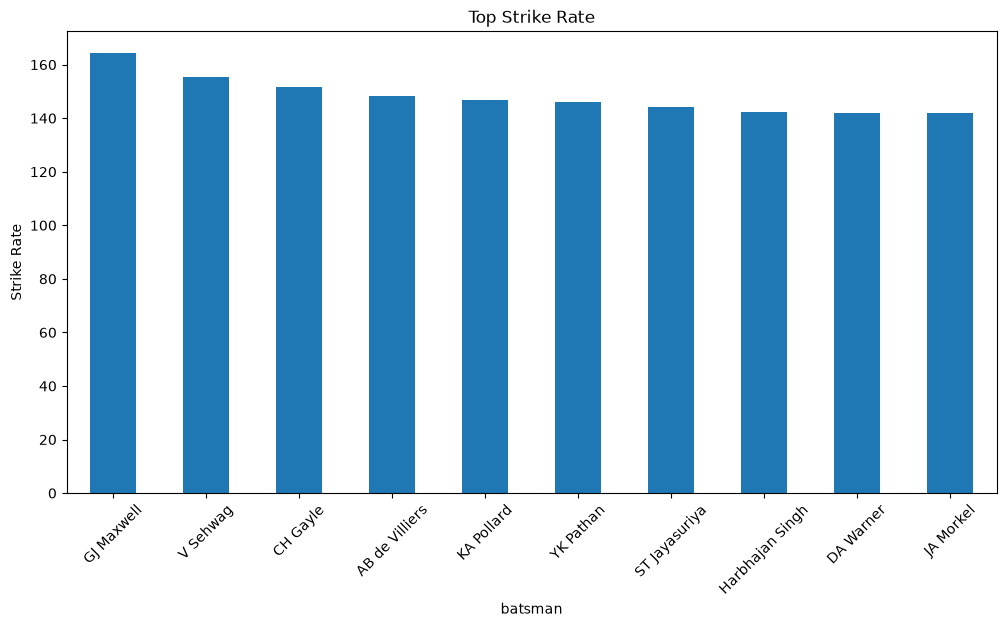

In [123]:
plt.figure(figsize=(12,6))

strike_rate.head(10).plot(kind="bar")

plt.title("Top Strike Rate")

plt.ylabel("Strike Rate")

plt.xticks(rotation=45)

plt.savefig(
    "../images/improved_strike_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

GJ Maxwell has the best strike rate among players who faced at least 500 legal deliveries.

In [124]:
boundaries = deliveries[
    deliveries["batsman_runs"].isin([4,6])
]

boundary_count = boundaries.groupby(
    "batsman"
).size()

balls = legal_balls.groupby(
    "batsman"
).size()

boundary_percentage = (
    boundary_count / balls
)*100

boundary_percentage = boundary_percentage.fillna(0)

qualified = balls >= 500

boundary_percentage = boundary_percentage[
    qualified
].sort_values(
    ascending=False
)

print(boundary_percentage.head(10))

batsman
V Sehwag           25.071225
GJ Maxwell         23.796791
CH Gayle           23.370693
ST Jayasuriya      23.120301
AC Gilchrist       22.140468
Harbhajan Singh    20.855615
DR Smith           20.521542
ML Hayden          20.471464
Q de Kock          20.218579
SR Watson          20.052770
dtype: float64


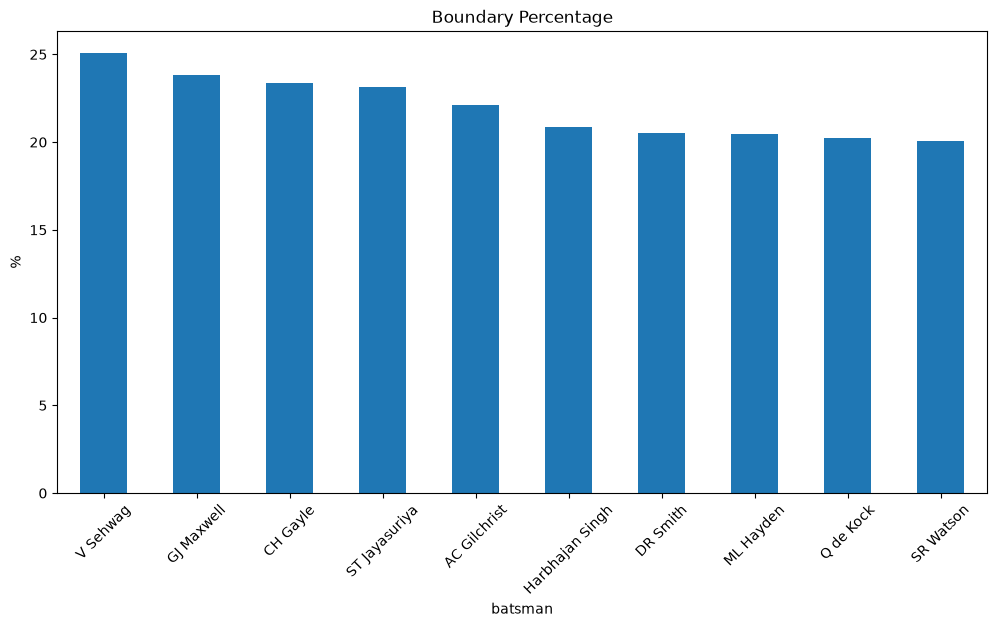

In [125]:
plt.figure(figsize=(12,6))

boundary_percentage.head(10).plot(kind="bar")

plt.title("Boundary Percentage")

plt.ylabel("%")

plt.xticks(rotation=45)

plt.savefig(
    "../images/boundary_percentage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

V Sehwag hits boundaries most frequently.

In [126]:
dot_balls = legal_balls[
    legal_balls["batsman_runs"]==0
]

dot = dot_balls.groupby(
    "batsman"
).size()

balls = legal_balls.groupby(
    "batsman"
).size()

dot_percentage = (
    dot/balls
)*100

dot_percentage = dot_percentage.fillna(0)

qualified = balls >= 500

dot_percentage = dot_percentage[
    qualified
].sort_values()

print(dot_percentage.head(10))

batsman
SPD Smith         29.969183
KM Jadhav         30.362538
AB de Villiers    30.834753
JP Duminy         31.140351
AD Mathews        31.826087
DA Miller         31.916817
F du Plessis      32.411067
SK Raina          32.476278
MS Dhoni          32.642089
JA Morkel         33.042213
dtype: float64


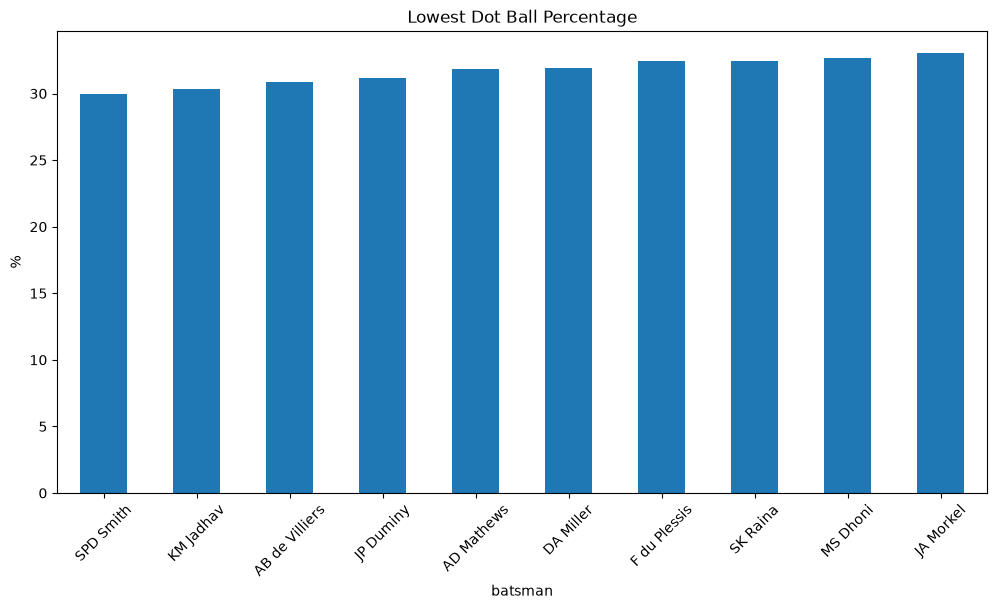

In [127]:
plt.figure(figsize=(12,6))

dot_percentage.head(10).plot(kind="bar")

plt.title("Lowest Dot Ball Percentage")

plt.ylabel("%")

plt.xticks(rotation=45)

plt.savefig(
    "../images/dot_ball_percentage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

SPD Smith has lowest dot ball percentage, indicating highly efficient scoring.

In [128]:
distribution = deliveries[
    "batsman_runs"
].value_counts().sort_index()

print(distribution)

batsman_runs
0    61148
1    55496
2     9705
3      509
4    17033
5       45
6     6523
Name: count, dtype: int64


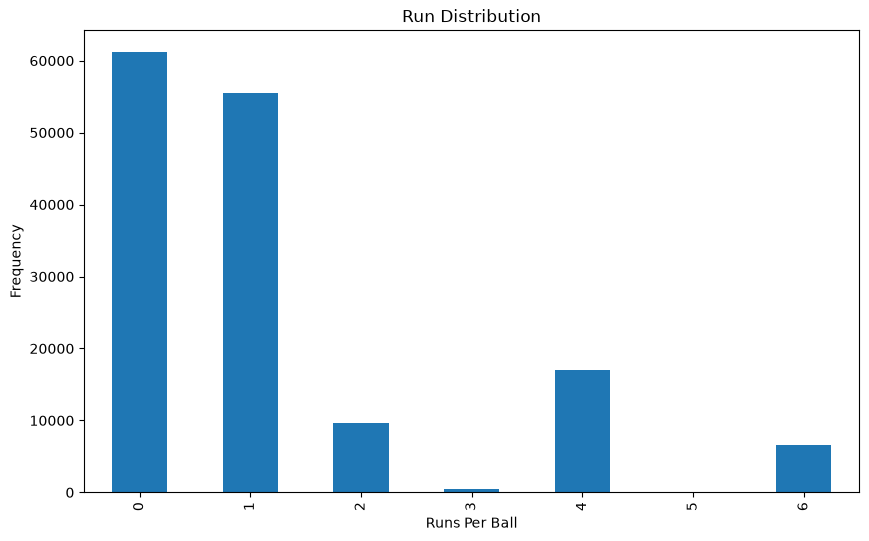

In [129]:
plt.figure(figsize=(10,6))

distribution.plot(kind="bar")

plt.title("Run Distribution")

plt.xlabel("Runs Per Ball")

plt.ylabel("Frequency")

plt.savefig(
    "../images/run_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

The score of 0 on a ball has highest frequency.

In [130]:
consistent = average.sort_values(
    ascending=False
)

print(consistent.head(10))

batsman
CH Gayle          41.022472
DA Warner         40.140000
LMP Simmons       39.962963
JP Duminy         39.860000
SE Marsh          39.507937
MEK Hussey        38.764706
AB de Villiers    38.307692
MS Dhoni          37.872340
V Kohli           37.483051
SPD Smith         37.239130
dtype: float64


In [132]:
highest_scores.to_csv(
    "../data/cleaned/highest_scores.csv",
    index=False
)

average.to_csv(
    "../data/cleaned/batting_average.csv"
)

strike_rate.to_csv(
    "../data/cleaned/strike_rate.csv"
)

In [133]:
import pandas as pd
import matplotlib.pyplot as plt

matches = pd.read_csv("../data/cleaned/matches_cleaned.csv")
deliveries = pd.read_csv("../data/cleaned/deliveries_cleaned.csv")

In [134]:
valid_wickets = deliveries[
    deliveries["dismissal_kind"].notna()
]

valid_wickets = valid_wickets[
    ~valid_wickets["dismissal_kind"].isin([
        "run out",
        "retired hurt",
        "obstructing the field"
    ])
]

wickets = valid_wickets.groupby("bowler").size()

wickets = wickets.sort_values(ascending=False)

print(wickets.head(10))

bowler
SL Malinga         154
A Mishra           134
Harbhajan Singh    127
PP Chawla          126
DJ Bravo           122
B Kumar            111
A Nehra            106
R Vinay Kumar      103
Z Khan             102
R Ashwin           100
dtype: int64


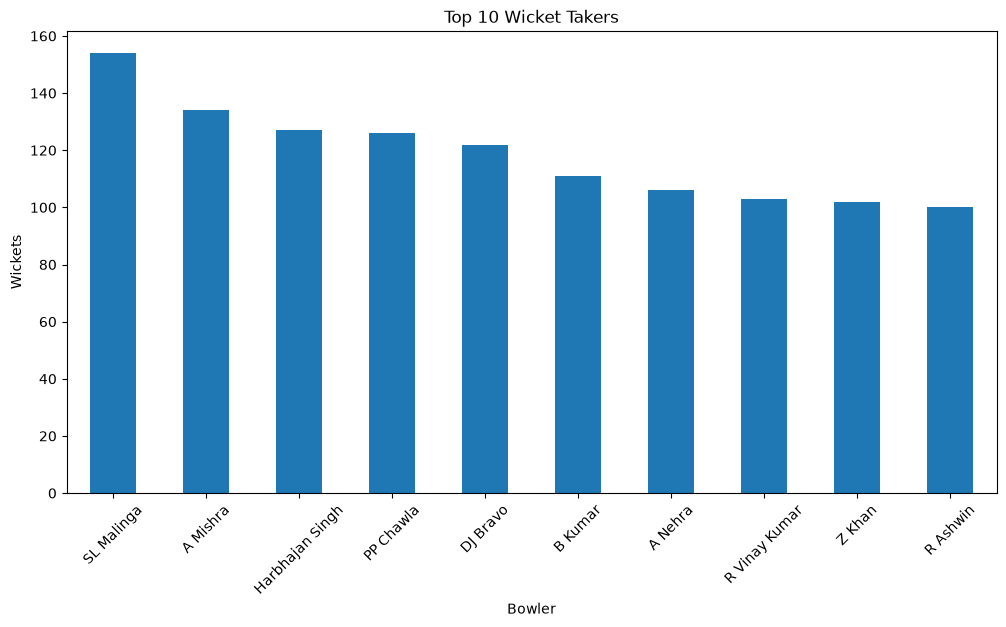

In [135]:
plt.figure(figsize=(12,6))

wickets.head(10).plot(kind="bar")

plt.title("Top 10 Wicket Takers")
plt.xlabel("Bowler")
plt.ylabel("Wickets")

plt.xticks(rotation=45)

plt.savefig(
    "../images/top_wickets.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

Sl Malinga is the highest wicket taker in the dataset.

In [136]:
legal = deliveries[
    (deliveries["wide_runs"] == 0) &
    (deliveries["noball_runs"] == 0)
]

In [137]:
runs = deliveries.groupby("bowler")["total_runs"].sum()

In [138]:
balls = legal.groupby("bowler").size()

In [139]:
overs = balls / 6

In [140]:
economy = runs / overs

economy = economy.replace([float("inf")], 0)

qualified = balls >= 300

economy = economy[qualified]

economy = economy.sort_values()

print(economy.head(10))

bowler
SP Narine           6.478509
R Ashwin            6.686463
A Kumble            6.770984
GD McGrath          6.777778
Rashid Khan         6.814815
DL Vettori          6.903475
DW Steyn            6.904070
M Muralitharan      6.930628
RE van der Merwe    6.975169
J Botha             7.072046
dtype: float64


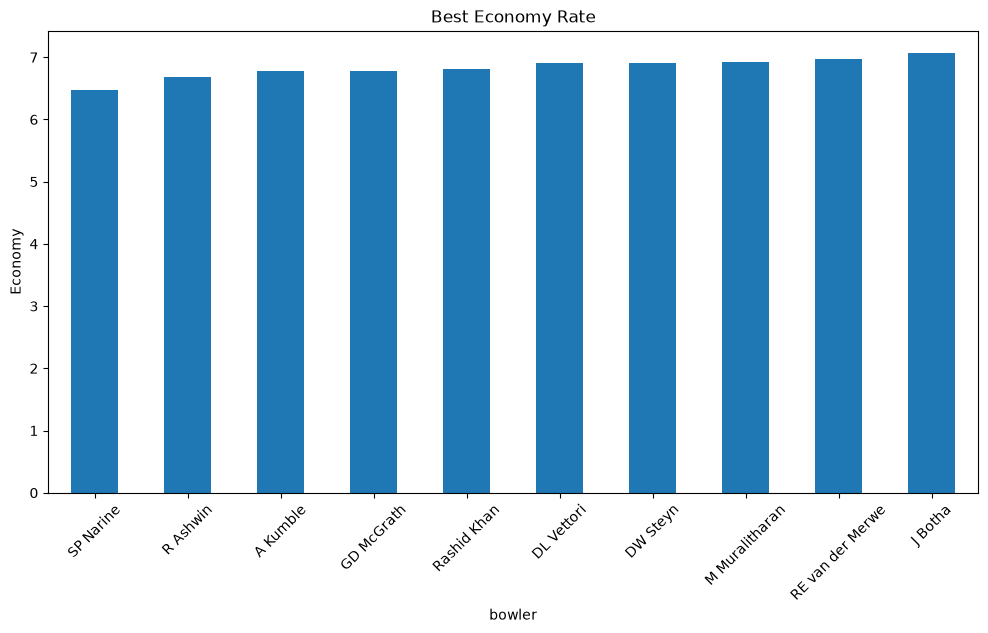

In [141]:
plt.figure(figsize=(12,6))

economy.head(10).plot(kind="bar")

plt.title("Best Economy Rate")

plt.ylabel("Economy")

plt.xticks(rotation=45)

plt.savefig(
    "../images/economy_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

SP Narine has best economy rate.

In [142]:
stats = pd.DataFrame({
    "balls": balls,
    "wickets": wickets
}).fillna(0)

In [143]:
stats = stats[stats["wickets"] > 0]

In [144]:
stats = stats[stats["balls"] >= 300]

In [145]:
stats["strike_rate"] = (
    stats["balls"] /
    stats["wickets"]
)

stats = stats.sort_values(
    "strike_rate"
)

print(stats.head(10))

                 balls  wickets  strike_rate
bowler                                      
Imran Tahir        716     47.0    15.234043
MF Maharoof        420     27.0    15.555556
DE Bollinger       576     37.0    15.567568
NM Coulter-Nile    563     36.0    15.638889
MR Marsh           315     20.0    15.750000
VY Mahesh          339     21.0    16.142857
AD Mascarenhas     308     19.0    16.210526
DJ Bravo          2018    122.0    16.540984
SL Malinga        2558    154.0    16.610390
S Aravind          760     45.0    16.888889


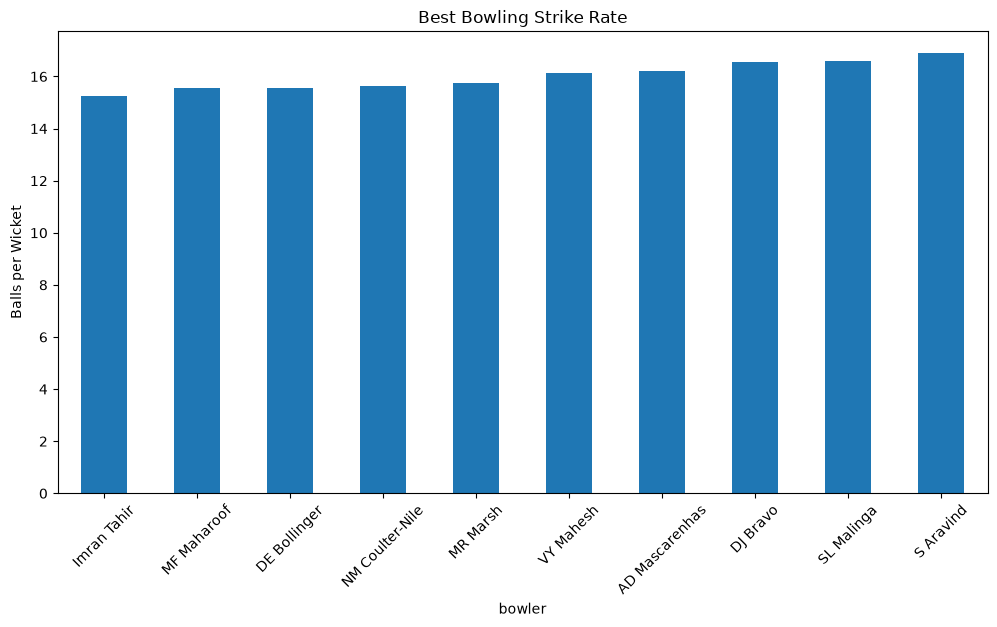

In [146]:
plt.figure(figsize=(12,6))

stats["strike_rate"].head(10).plot(
    kind="bar"
)

plt.title("Best Bowling Strike Rate")

plt.ylabel("Balls per Wicket")

plt.xticks(rotation=45)

plt.savefig(
    "../images/bowling_strike_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

Imran Tahir has best bowling strike rate.

In [147]:
stats["runs"] = runs

stats["average"] = (
    stats["runs"] /
    stats["wickets"]
)

stats = stats.sort_values(
    "average"
)

print(stats.head(10))

                 balls  wickets  strike_rate  runs    average
bowler                                                       
AD Mascarenhas     308     19.0    16.210526   365  19.210526
DE Bollinger       576     37.0    15.567568   716  19.351351
SL Malinga        2558    154.0    16.610390  3034  19.701299
MF Maharoof        420     27.0    15.555556   532  19.703704
NM Coulter-Nile    563     36.0    15.638889   739  20.527778
MR Marsh           315     20.0    15.750000   420  21.000000
Imran Tahir        716     47.0    15.234043  1002  21.319149
MA Starc           580     34.0    17.058824   725  21.323529
Rashid Khan        324     17.0    19.058824   368  21.647059
B Kumar           1981    111.0    17.846847  2410  21.711712


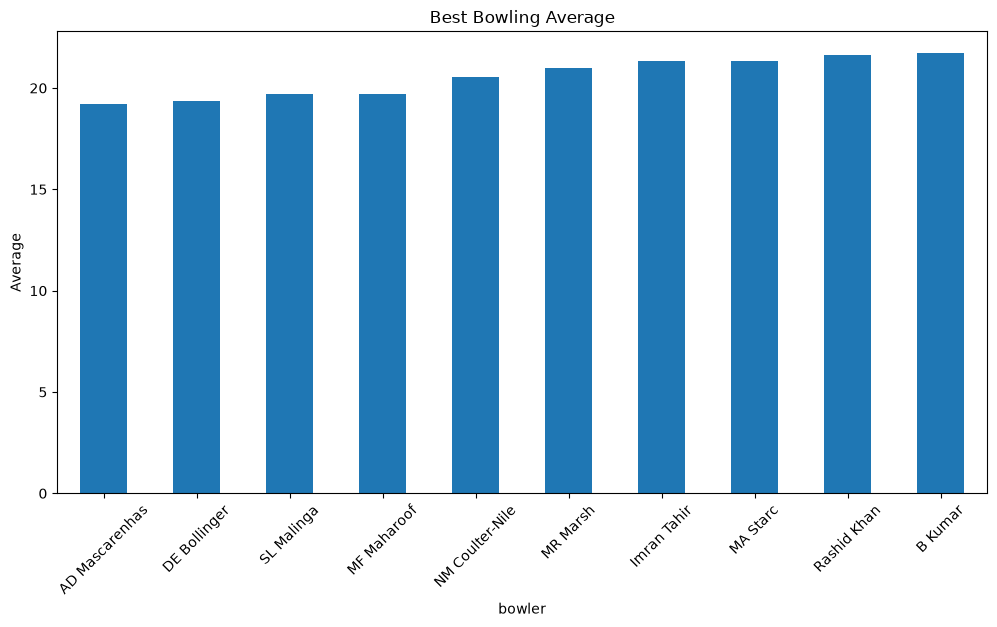

In [148]:
plt.figure(figsize=(12,6))

stats["average"].head(10).plot(
    kind="bar"
)

plt.title("Best Bowling Average")

plt.ylabel("Average")

plt.xticks(rotation=45)

plt.savefig(
    "../images/bowling_average.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

AD Mascarenhas has best bowling average.

In [149]:
dot = legal[
    legal["total_runs"] == 0
]

In [150]:
dot = dot.groupby(
    "bowler"
).size()

In [151]:
dot_percentage = (
    dot / balls
) * 100

dot_percentage = dot_percentage.fillna(0)

qualified = balls >= 300

dot_percentage = dot_percentage[
    qualified
]

dot_percentage = dot_percentage.sort_values(
    ascending=False
)

print(dot_percentage.head(10))

bowler
DW Steyn           47.383721
GD McGrath         47.222222
BW Hilfenhaus      46.505376
IC Pandey          45.887446
S Sreesanth        45.340909
MG Johnson         44.274121
DP Nannes          44.117647
DE Bollinger       44.097222
NM Coulter-Nile    43.872114
RJ Harris          43.750000
dtype: float64


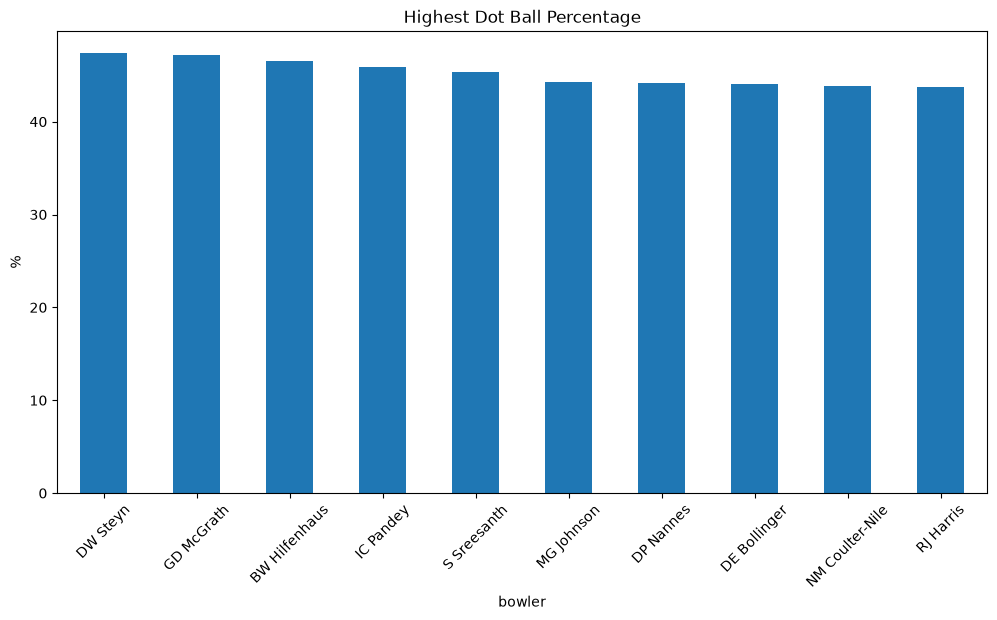

In [152]:
plt.figure(figsize=(12,6))

dot_percentage.head(10).plot(
    kind="bar"
)

plt.title("Highest Dot Ball Percentage")

plt.ylabel("%")

plt.xticks(rotation=45)

plt.savefig(
    "../images/dot_ball_percentage_bowler.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

DW Steyn has highest dot ball percentage.

In [153]:
over_runs = legal.groupby(
    ["match_id", "inning", "bowler", "over"]
)["total_runs"].sum().reset_index()

In [154]:
maidens = over_runs[
    over_runs["total_runs"] == 0
]

In [155]:
maidens = maidens.groupby(
    "bowler"
).size()

maidens = maidens.sort_values(
    ascending=False
)

print(maidens.head(10))

bowler
P Kumar           14
DW Steyn          10
IK Pathan          9
SL Malinga         9
B Kumar            9
DS Kulkarni        8
Z Khan             7
R Ashwin           7
Sandeep Sharma     6
S Sreesanth        5
dtype: int64


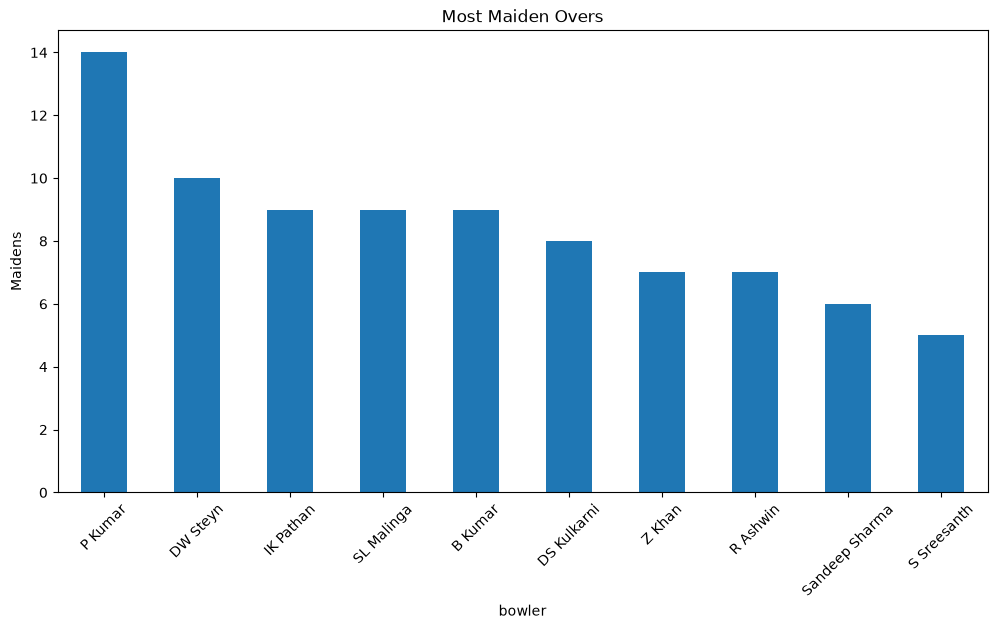

In [156]:
plt.figure(figsize=(12,6))

maidens.head(10).plot(kind="bar")

plt.title("Most Maiden Overs")

plt.ylabel("Maidens")

plt.xticks(rotation=45)

plt.savefig(
    "../images/maiden_overs.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

P Kumar has highest number of maiden overs.

In [157]:
figures = valid_wickets.groupby(
    ["match_id", "bowler"]
).size().reset_index(
    name="wickets"
)

In [158]:
figures = figures.sort_values(
    "wickets",
    ascending=False
)

print(figures.head(10))

      match_id         bowler  wickets
4109       616        A Zampa        6
579         83  Sohail Tanvir        6
666         98       A Mishra        5
1783       265       I Sharma        5
84          13         AJ Tye        5
1931       287       MM Patel        5
3009       449    JP Faulkner        5
1615       238     SL Malinga        5
795        119       A Kumble        5
2103       313      RA Jadeja        5


In [159]:
stats.to_csv(
    "../data/cleaned/bowling_statistics.csv"
)

maidens.to_csv(
    "../data/cleaned/maiden_overs.csv"
)

figures.to_csv(
    "../data/cleaned/best_figures.csv",
    index=False
)

In [160]:
print(deliveries.columns.tolist())

['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs', 'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs', 'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed', 'dismissal_kind', 'fielder']
